# Машинное обучение, ФКН ВШЭ

# Практическое задание 6. Бустинговое

## О задании

В этом задании вам предстоит вручную запрограммировать один из самых мощных алгоритмов машинного обучения — бустинг. Однако с большой силой приходит и большая ответственность, поэтому придется научиться им пользоваться

In [1]:
from warnings import filterwarnings

import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set(style='darkgrid')
filterwarnings('ignore')

Мы будем работать с датасетом по предсказанию гендера. Никакие фичи мы придумывать не будем, но если вам интересно, в датасете имеется:

- region — регион, в котором проводили опрос
- age — возраст опрошенного
- year — год опроса
- race — этническая принадлежность
- sch — количество классов образования
- empstat — статус трудоустройства
- occ — код профессии
- ind — код индустрии, в которой человек работает
- annhrs — число часов работы в год
- hrwage — почасовая оплата
- icwage — суммарная оплата в год
- occupation — должность

Целевая метрика ROC-AUC, потому что мы непритязательны и это не фокус этой домашки



In [2]:
df = pd.read_parquet(
    "/kaggle/input/datasets/alexetmercedes/test-pq/hw6_dataset.pq"
)

X = df.drop("sex", axis=1)
y = df["sex"]

Пока что мы временно выкинем колонку с должностью, но мы к ней обязательно вернемся

Разделим на обучающую, валидационную и тестовую выборки по годам, чтобы предсказывать будущее, а не прошлое

In [3]:
X_train = X[X["year"] < 2011].drop("occupation", axis=1).values
y_train = y[X["year"] < 2011].values

X_valid = X[X["year"] == 2011].drop("occupation", axis=1).values
y_valid = y[X["year"] == 2011].values

X_test = X[X["year"] == 2013].drop("occupation", axis=1).values
y_test = y[X["year"] == 2013].values

X_train.shape, X_valid.shape, X_test.shape

((236640, 10), (53857, 10), (53790, 10))

Домашнее задание имеет нелинейную структуру. В нём есть <font color='lightcoral'>📌 **обязательные**</font> части, без которых будет тяжко <font color='lightcoral'>**(6 баллов)**</font>, и целая куча 💠 **опциональных**, которыми можно добить оценку до 10, делайте то, что нравится больше! **Музыкальный бонус** идёт отдельно, за него можно получить ещё 0.5 балла.

---

## 📌 Задание 1. Базовый градиентный бустинг (4 балла)

Это задание <font color='lightcoral'>**📌 обязательное**</font>, без него домашка не имеет смысла! Ещё раз обращаем внимание, что **опциональные** задания помечены 💠

Первая часть посвящена реализации собственного градиентного бустинга. Обращаем внимание, что пользоваться готовыми реализациями <font color='lightcoral'>**нельзя**</font>, если специально не оговорено. На все <font color='lightcoral'>**вопросы**</font> должен быть <font color='lightcoral'>**ответ**</font>. В заданиях, где нужно делать параметры, часто есть референсы из других библиотек. На случай, если объяснение из ноутбука непонятно, советуем обратиться к соответствующей документации и пощупать, как это делается там

Вам нужно дописать код в файлике `boosting.py`. Для вас уже подготовлен шаблон класса `Boosting`, вы можете менять его по своему усмотрению.

### Инструкции для функций:

#### `__init__`

Существующие параметры:
- `base_model_class` — класс базовой модели нашего бустинга
- `base_model_params` — словарь с гиперпараметрами для базовой модели
- `n_estimators` — какое количество базовых моделей нужно обучить
- `learning_rate` — темп обучения, должен быть из полуинтервала $(0, 1]$
- `random_state`— в роли рандом стейта
- `verbose` — для тех, кому не нравится загадочность, можно включить и увидеть, сколько еще ждать конца обучения

#### `fit`

В `fit` приходит выборка, на которой мы обучаем новые базовые модели

1. Сначала нам нужно сделать какую-то нулевую модель, сделать предсказания (в шаблоне это нулевая модель, соответственно предсказания это просто `np.zeros`).
2. После этого нужно обучить `n_estimators` базовых моделей (как и на что обучаются базовые модели смотрите в лекциях и семинарах).
3. После каждой обученной базовой модели мы должны обновить текущие предсказания, посчитать ошибку на выборке (используем `loss_fn` для этого) и найти новую оптимальную гамму

#### `partial_fit`

В `partial_fit` передаются данные `X: np.ndarray, y: np.ndarray` для одного шага бустинга: обучаем следующую базовую модель на антиградиенте и обновляем ансамбль.

#### `predict_proba`

В `predict_proba` приходит любая выборка, нужно предсказать вероятности для неё. Суммируем предсказания базовых моделей на этой выборке (не забываем про гаммы) и накидываем сигмоиду

In [4]:
%%writefile boosting.py

from __future__ import annotations

from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import roc_auc_score

from tqdm.auto import tqdm

from sklearn.base import ClassifierMixin


class CatEncoder:

    def __init__(self, cat_features):
        self.cat_features = cat_features
        self.statistics = {}

    def fit(self, x, y):
        for feature in self.cat_features:
            values = x[:, feature]
            feature_stats = {}
            for value in np.unique(values):
                mask = values == value
                feature_stats[value] = np.mean(y[mask] == 1)
            self.statistics[feature] = feature_stats
        return self

    def transform(self, x):
        x_new = x.copy()
        for feature in self.cat_features:
            stats = self.statistics[feature]
            encoded = []
            for value in x[:, feature]:
                encoded.append(stats.get(value, 0.5))
            x_new[:, feature] = encoded
        return x_new.astype(float)


class Boosting(ClassifierMixin):

    def __init__(
        self,
        base_model_class = DecisionTreeRegressor,
        base_model_params: dict | None = None,
        n_estimators: int = 20,
        learning_rate: float = 0.05,
        random_state: int | None = None,
        verbose: bool = True,
        early_stopping_rounds: int | None = 0,
        eval_metric: str | None = None,
        cat_features=None,
    ):
        super().__init__()

        self.base_model_class = base_model_class
        self.base_model_params = {} if base_model_params is None else base_model_params

        self.n_estimators = n_estimators
        self.learning_rate = learning_rate

        self.models = []
        self.gammas = []

        self.random_state = random_state  # не забудьте вставить его везде, где у вас возникает рандом
        self.verbose = verbose

        self.cat_features = [] if cat_features is None else cat_features
        self.encoder = None

        self.early_stopping_rounds = early_stopping_rounds
        self.eval_metric = eval_metric

        self.history = defaultdict(list)  # {"train_roc_auc": [], "train_loss": [], ...}

        self.sigmoid = lambda x: 1 / (1 + np.exp(-x))
        self.loss_fn = lambda y, z: -np.log(self.sigmoid(y * z)).mean()
        self.grad_fn = lambda y, z: y / (1+np.exp(y*z))  # Исправьте формулу на правильную.

    def partial_fit(self, X: np.ndarray, y: np.ndarray) -> None:
        antigrad = self.grad_fn(y, self.train_predictions)
        params = self.base_model_params.copy()
        if self.random_state is not None:
            params["random_state"] = self.random_state
        model = self.base_model_class(**params)
        model.fit(X, antigrad)
        new_predictions = model.predict(X)
        gamma = self._find_optimal_gamma(
            y,
            self.train_predictions,
            new_predictions
        )
        self.models.append(model)
        self.gammas.append(gamma)
        self.train_predictions += self.learning_rate * gamma * new_predictions


    def fit(
            self,
            X_train: np.ndarray,
            y_train: np.ndarray,
            eval_set: tuple[np.ndarray, np.ndarray] | None = None,
            use_best_model: bool = False,
    ) -> None:
        self.classes_ = np.unique(y_train)  # не рекомендуется убирать, нужно для калибровки
        self.models = []
        self.gammas = []
        self.history = defaultdict(list)

        if len(self.cat_features) > 0:
            self.encoder = CatEncoder(self.cat_features)
            self.encoder.fit(X_train, y_train)

            X_train = self.encoder.transform(X_train)

            if eval_set is not None:
                X_valid, y_valid = eval_set
                X_valid = self.encoder.transform(X_valid)
                eval_set = (X_valid, y_valid)

        self.train_predictions = np.zeros(X_train.shape[0])

        if eval_set is not None:
            X_valid, y_valid = eval_set
            valid_predictions = np.zeros(X_valid.shape[0])
        else:
            X_valid, y_valid = None, None
            valid_predictions = None

        best_score = None
        best_iteration = 0
        bad_rounds = 0

        estimator_range = range(self.n_estimators)
        if self.verbose:
            estimator_range = tqdm(estimator_range)

        # ! YOUR CODE HERE !
        for i in estimator_range:
            self.partial_fit(X_train, y_train)
            train_loss = self.loss_fn(y_train, self.train_predictions)
            train_auc = roc_auc_score(y_train == 1, self.sigmoid(self.train_predictions))
            self.history["train_loss"].append(train_loss)
            self.history["train_roc_auc"].append(train_auc)
            if eval_set is not None:
                last_model = self.models[-1]
                last_gamma = self.gammas[-1]
                valid_predictions += (
                    self.learning_rate
                    * last_gamma
                    * last_model.predict(X_valid)
                )
                valid_loss = self.loss_fn(y_valid, valid_predictions)
                valid_auc = roc_auc_score(y_valid == 1, self.sigmoid(valid_predictions))
                self.history["valid_loss"].append(valid_loss)
                self.history["valid_roc_auc"].append(valid_auc)
                metric_name = self.eval_metric
                if metric_name is None:
                    metric_name = "valid_loss"
                current_score = self.history[metric_name][-1]
                if "loss" in metric_name:
                    is_better = best_score is None or current_score < best_score
                else:
                    is_better = best_score is None or current_score > best_score
                if is_better:
                    best_score = current_score
                    best_iteration = i
                    bad_rounds = 0
                else:
                    bad_rounds += 1

                if self.early_stopping_rounds and bad_rounds >= self.early_stopping_rounds:
                    if self.verbose:
                        print(f"Early stopping on iteration {i + 1}")
                    break

        if use_best_model and eval_set is not None and self.early_stopping_rounds:
            self.models = self.models[:best_iteration + 1]
            self.gammas = self.gammas[:best_iteration + 1]

        # чтобы было удобнее смотреть
        for key in self.history:
            self.history[key] = np.array(self.history[key])

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        # ! YOUR CODE HERE !
        if self.encoder is not None:
            X = self.encoder.transform(X)
        predictions = np.zeros(X.shape[0])
        for i in range(len(self.models)):
            predictions += (
                self.learning_rate
                * self.gammas[i]
                *self.models[i].predict(X)
            )
        proba_1 = self.sigmoid(predictions)
        proba_0 = 1 - proba_1
        return np.vstack([proba_0, proba_1]).T


    def plot_history(self, keys):
        if isinstance(keys, str):
            keys = [keys]
        for key in keys:
            plt.plot(self.history[key], label = key)
        plt.xlabel("iteration")
        plt.ylabel("metric")
        plt.legend()
        plt.grid()
        plt.show()


    def _find_optimal_gamma(
        self,
        y: np.ndarray,
        old_predictions: np.ndarray, 
        new_predictions: np.ndarray
    ) -> float:
        gammas = np.linspace(start=0, stop=1, num=100)
        losses = [
            self.loss_fn(y, old_predictions + gamma * new_predictions)
            for gamma in gammas
        ]
        return gammas[np.argmin(losses)]

    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        return roc_auc_score(y == 1, self.predict_proba(X)[:, 1])


Writing boosting.py


In [5]:
import importlib
import boosting

importlib.reload(boosting)

from boosting import Boosting

### Проверка кода

In [6]:
boosting = Boosting(
    verbose=True,
    base_model_params=dict(max_depth=5),
    n_estimators=50,
    random_state=69, # не забывайте фиксировать, пожалуйста
)

boosting.fit(X_train, y_train)

assert len(boosting.models) == boosting.n_estimators
assert len(boosting.gammas) == boosting.n_estimators

assert boosting.predict_proba(X_test).shape == (X_test.shape[0], 2), "prediction shapes are incorrect"
assert np.array_equal(boosting.history["train_loss"], np.sort(boosting.history["train_loss"])[::-1]), "train loss is not decreasing"

assert boosting.predict_proba(X_test).shape == (X_test.shape[0], 2)

# здесь и далее работаем с метрикой ROC-AUC
print(f'Train ROC-AUC {boosting.score(X_train, y_train):.4f}')
print(f'Valid ROC-AUC {boosting.score(X_valid, y_valid):.4f}')
print(f'Test ROC-AUC {boosting.score(X_test, y_test):.4f}')

  0%|          | 0/50 [00:00<?, ?it/s]

Train ROC-AUC 0.8013
Valid ROC-AUC 0.7247
Test ROC-AUC 0.7196


---

## Задание 2. Имплементация гиперпараметров (📌 1 балл |💠 8.25 балла)

Бустинг, как метод агрегации, предлагает несколько вариантов регуляризации.

В этом пункте мы будем делать кучу самых разных гиперпараметров, каждый из них прекрасен по-своему, но полноценно их эффект получится ощутить лишь на этапе их перебора (кроме, пожалуй, `rsm`), поэтому делать третью часть до второй не рекомендуется

<font color='lightcoral'>**Важно!**</font> После добавления каждого параметра проверьте, как это повлияет на качество. Специально крутить параметры не нужно, но важно увидеть, что перформанс модели изменился, в худшую или в лучшую сторону. Для этого какие-то параметры нужны, пусть и от балды, <font color='lightcoral'>**гарантии, что дефолтные параметры подойдут, нет**</font>. Лучше всего это видно по графикам обучения <font color='lightcoral'>**на трейне и валидации**</font>, рекомендуется смотреть именно на них

### 📌 2.1. Борьба с переобучением (0.5 балла)

Как известно, бустинги бывают склонны к переобучению. Чтобы этого не допустить, можно контролировать процесс обучения и проверять критерий останова на валидации прямо во время обучения. Реализуйте такую процедуру, не забудьте, что всю предобработку, что вы будете в дальнейшем делать для трейна, нужно будет повторить на валидации

Добавьте в вашу модель:
- `early_stopping_rounds: int | None = 0` — число раундов для критерия останова. Если качество ухудшается на протяжении всех раундов подряд, останавливаем обучение
- `eval_metric: str | None = None` — метрика, на которую смотрим, чтобы остановить обучение, может быть ключом из `model.history`
- `plot_history(self, keys: str | Iterable[str])` — метод, который строит график изменения метрики по ключам из `model.history`

И конкретно в метод `model.fit`:
- `eval_set: tuple[np.ndarray] | None = None` — валидационная выборка `X_valid: np.ndarray, y_valid: np.ndarray`, на которой будем проверять переобучение
- `use_best_model: bool = False` — использовать лучшую модель, или нет. Если да, то отрезаем гаммы и модели вплоть до той, на которой остановились, минус `early_stopping_rounds`, т.е самой лучшей, после которой качество только падает

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td colspan="3" align="center"><code>early_stopping_rounds</code>, <code>eval_set</code></td>
</tr>
</table>

</div>

Продемонстрируйте, что все работает

In [7]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
boosting_es = Boosting(
    verbose=True,
    base_model_params=dict(max_depth=5),
    n_estimators=200,
    random_state=69,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
)

boosting_es.fit(
    X_train, 
    y_train, 
    eval_set=(X_valid, y_valid), 
    use_best_model= True,
)


print(len(boosting_es.models))
# здесь и далее работаем с метрикой ROC-AUC
print(f'Train ROC-AUC {boosting_es.score(X_train, y_train):.4f}')
print(f'Valid ROC-AUC {boosting_es.score(X_valid, y_valid):.4f}')
print(f'Test ROC-AUC {boosting_es.score(X_test, y_test):.4f}')

  0%|          | 0/200 [00:00<?, ?it/s]

Early stopping on iteration 37
27
Train ROC-AUC 0.7976
Valid ROC-AUC 0.7277
Test ROC-AUC 0.7228


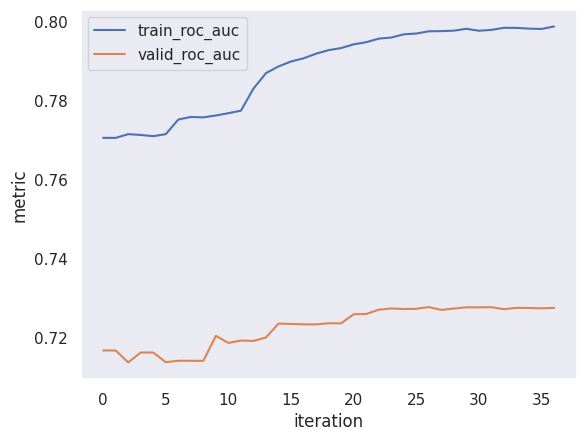

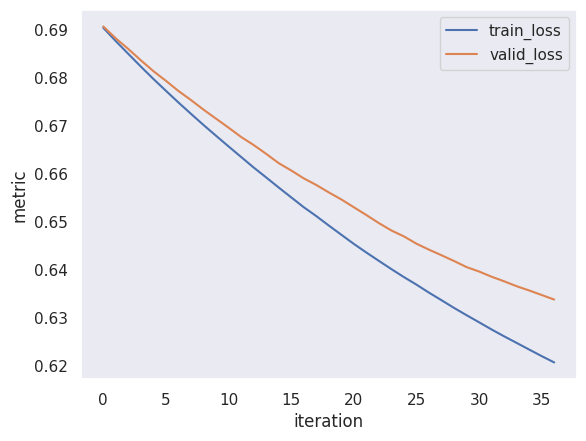

In [8]:
boosting_es.plot_history(["train_roc_auc", "valid_roc_auc"])
boosting_es.plot_history(["train_loss", "valid_loss"])

### 📌 2.2. Категории 2.0 (0.5 балла)

Пока что для простоты картины мы игнорировали категориальные признаки. <font color='#c4bf0a'>**CatBoost**</font> в частности предлагает один из самых эффективных и быстрых вариантов кодировки категорий, который мы попробуем повторить

> Основная идея в том, что важны не сами категории, а значения целевой переменной, которые имеют объекты этой категории. Каждый категориальный признак мы заменим средним значением целевой переменной по всем объектам этой же категории:

$$
g_j(x, X) = \frac{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)][y_i = +1]}{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)]}
$$


Добавьте в модель вот это:
- `cat_features: Iterable | None` — категориальные признаки для кодирования
- `_cat_fit(self, X: np.array, y: np.ndarray)` — внутренний метод для построения счетчиков
- `_cat_transform(self, X: np.ndarray)` — внутренний метод для применения счетчиков

Лмбо сделайте энкодер отдельным классом с аналогичными методами `fit` и `transform`, это даже лучше. Его нужно прогнать всего раз для каждой из выборок

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>-</code></td>
<td align="center"><code>-</code></td>
<td align="center"><code>cat_features</code></td>
</tr>
</table>

</div>

Закодируйте переменные, которые вы хотите считать категориальными, с помощью счётчиков (готовые реализации брать нельзя) и покажите эффект. Помните, что все должно быть векторизовано и красиво

In [9]:
# вернем occupation туда, где ему самое место, но это не единственная кат фича!

X_train = X[X["year"] < 2011].values
X_valid = X[X["year"] == 2011].values
X_test = X[X["year"] == 2013].values

In [10]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
cat_features = [6, 10]
boosting_cat = Boosting(
    verbose=True,
    base_model_params=dict(max_depth=5),
    n_estimators=200,
    learning_rate=0.05,
    random_state=69,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
    cat_features=cat_features,
)

boosting_cat.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)

print(len(boosting_cat.models))
print(f"Train ROC-AUC {boosting_cat.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC {boosting_cat.score(X_valid, y_valid):.4f}")
print(f"Test ROC-AUC {boosting_cat.score(X_test, y_test):.4f}")

  0%|          | 0/200 [00:00<?, ?it/s]

Early stopping on iteration 16
6
Train ROC-AUC 0.8706
Valid ROC-AUC 0.8072
Test ROC-AUC 0.8011


### 💠 2.3. Категории 3.0 (0.5 балла)

Увы, закодированные признаки сами по себе являются классификаторами и, обучаясь на них, мы допускаем утечку целевой переменной в признаки, но с этим можно жить, в частности $\text{OrderedBoosting}$ это одна из главных фишек <font color='#c4bf0a'>**CatBoost**</font>, была. Почитайте [статью](https://arxiv.org/pdf/1706.09516), она интересная

Реализуйте подсчет счетчиков так, чтобы кодировка категории была только по объектам. расположенным выше в датасете (например, если выборка отсортирована каким-либо образом)

Методы добавлять не нужно, разве что очень хочется, предполагается, что это дефолтное поведение бустинга

In [11]:
%%writefile boosting_opt.py
from __future__ import annotations

from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import roc_auc_score

from tqdm.auto import tqdm

from sklearn.base import ClassifierMixin


class CatEncoder:

    def __init__(self, cat_features):
        self.cat_features = cat_features
        self.statistics = {}

    def fit(self, x, y):
        for feature in self.cat_features:
            values = x[:, feature]
            feature_stats = {}
            for value in np.unique(values):
                mask = values == value
                feature_stats[value] = np.mean(y[mask] == 1)
            self.statistics[feature] = feature_stats
        return self

    def transform(self, x):
        x_new = x.copy()
        for feature in self.cat_features:
            stats = self.statistics[feature]
            encoded = []
            for value in x[:, feature]:
                encoded.append(stats.get(value, 0.5))
            x_new[:, feature] = encoded
        return x_new.astype(float)

    def fit_transform(self, x, y):
        x_new = x.copy()
        for feature in self.cat_features:
            values = x[:, feature]

            positive_counts = {}
            total_counts = {}
            encoded = []

            for i in range(x.shape[0]):
                value = values[i]

                if value in total_counts:
                    encoded.append(
                        (positive_counts[value] + 0.5)
                        / (total_counts[value] + 1)
                    )
                else:
                    encoded.append(0.5)
                if value not in total_counts:
                    total_counts[value] = 0
                    positive_counts[value] = 0
                total_counts[value] += 1
                positive_counts[value] += int(y[i] == 1)
            x_new[:, feature] = encoded

        self.fit(x, y)
        return x_new.astype(float)




class Boosting(ClassifierMixin):

    def __init__(
        self,
        base_model_class = DecisionTreeRegressor,
        base_model_params: dict | None = None,
        n_estimators: int = 20,
        learning_rate: float = 0.05,
        random_state: int | None = None,
        verbose: bool = True,
        early_stopping_rounds: int | None = 0,
        eval_metric: str | None = None,
        cat_features=None,
    ):
        super().__init__()

        self.base_model_class = base_model_class
        self.base_model_params = {} if base_model_params is None else base_model_params

        self.n_estimators = n_estimators
        self.learning_rate = learning_rate

        self.models = []
        self.gammas = []

        self.random_state = random_state  # не забудьте вставить его везде, где у вас возникает рандом
        self.verbose = verbose

        self.cat_features = [] if cat_features is None else cat_features
        self.encoder = None

        self.early_stopping_rounds = early_stopping_rounds
        self.eval_metric = eval_metric

        self.history = defaultdict(list)  # {"train_roc_auc": [], "train_loss": [], ...}

        self.sigmoid = lambda x: 1 / (1 + np.exp(-x))
        self.loss_fn = lambda y, z: -np.log(self.sigmoid(y * z)).mean()
        self.grad_fn = lambda y, z: y / (1+np.exp(y*z))  # Исправьте формулу на правильную.

    def partial_fit(self, X: np.ndarray, y: np.ndarray) -> None:
        antigrad = self.grad_fn(y, self.train_predictions)
        params = self.base_model_params.copy()
        if self.random_state is not None:
            params["random_state"] = self.random_state
        model = self.base_model_class(**params)
        model.fit(X, antigrad)
        new_predictions = model.predict(X)
        gamma = self._find_optimal_gamma(
            y,
            self.train_predictions,
            new_predictions
        )
        self.models.append(model)
        self.gammas.append(gamma)
        self.train_predictions += self.learning_rate * gamma * new_predictions


    def fit(
            self,
            X_train: np.ndarray,
            y_train: np.ndarray,
            eval_set: tuple[np.ndarray, np.ndarray] | None = None,
            use_best_model: bool = False,
    ) -> None:
        self.classes_ = np.unique(y_train)  # не рекомендуется убирать, нужно для калибровки
        self.models = []
        self.gammas = []
        self.history = defaultdict(list)

        if len(self.cat_features) > 0:
            self.encoder = CatEncoder(self.cat_features)

            X_train = self.encoder.fit_transform(X_train, y_train)

            if eval_set is not None:
                X_valid, y_valid = eval_set
                X_valid = self.encoder.transform(X_valid)
                eval_set = (X_valid, y_valid)

        self.train_predictions = np.zeros(X_train.shape[0])

        if eval_set is not None:
            X_valid, y_valid = eval_set
            valid_predictions = np.zeros(X_valid.shape[0])
        else:
            X_valid, y_valid = None, None
            valid_predictions = None

        best_score = None
        best_iteration = 0
        bad_rounds = 0

        estimator_range = range(self.n_estimators)
        if self.verbose:
            estimator_range = tqdm(estimator_range)

        # ! YOUR CODE HERE !
        for i in estimator_range:
            self.partial_fit(X_train, y_train)
            train_loss = self.loss_fn(y_train, self.train_predictions)
            train_auc = roc_auc_score(y_train == 1, self.sigmoid(self.train_predictions))
            self.history["train_loss"].append(train_loss)
            self.history["train_roc_auc"].append(train_auc)
            if eval_set is not None:
                last_model = self.models[-1]
                last_gamma = self.gammas[-1]
                valid_predictions += (
                    self.learning_rate
                    * last_gamma
                    * last_model.predict(X_valid)
                )
                valid_loss = self.loss_fn(y_valid, valid_predictions)
                valid_auc = roc_auc_score(y_valid == 1, self.sigmoid(valid_predictions))
                self.history["valid_loss"].append(valid_loss)
                self.history["valid_roc_auc"].append(valid_auc)
                metric_name = self.eval_metric
                if metric_name is None:
                    metric_name = "valid_loss"
                current_score = self.history[metric_name][-1]
                if "loss" in metric_name:
                    is_better = best_score is None or current_score < best_score
                else:
                    is_better = best_score is None or current_score > best_score
                if is_better:
                    best_score = current_score
                    best_iteration = i
                    bad_rounds = 0
                else:
                    bad_rounds += 1

                if self.early_stopping_rounds and bad_rounds >= self.early_stopping_rounds:
                    if self.verbose:
                        print(f"Early stopping on iteration {i + 1}")
                    break

        if use_best_model and eval_set is not None and self.early_stopping_rounds:
            self.models = self.models[:best_iteration + 1]
            self.gammas = self.gammas[:best_iteration + 1]

        # чтобы было удобнее смотреть
        for key in self.history:
            self.history[key] = np.array(self.history[key])

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        # ! YOUR CODE HERE !
        if self.encoder is not None:
            X = self.encoder.transform(X)
        predictions = np.zeros(X.shape[0])
        for i in range(len(self.models)):
            predictions += (
                self.learning_rate
                * self.gammas[i]
                *self.models[i].predict(X)
            )
        proba_1 = self.sigmoid(predictions)
        proba_0 = 1 - proba_1
        return np.vstack([proba_0, proba_1]).T


    def plot_history(self, keys):
        if isinstance(keys, str):
            keys = [keys]
        for key in keys:
            plt.plot(self.history[key], label = key)
        plt.xlabel("iteration")
        plt.ylabel("metric")
        plt.legend()
        plt.grid()
        plt.show()


    def _find_optimal_gamma(
        self,
        y: np.ndarray,
        old_predictions: np.ndarray, 
        new_predictions: np.ndarray
    ) -> float:
        gammas = np.linspace(start=0, stop=1, num=100)
        losses = [
            self.loss_fn(y, old_predictions + gamma * new_predictions)
            for gamma in gammas
        ]
        return gammas[np.argmin(losses)]

    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        return roc_auc_score(y == 1, self.predict_proba(X)[:, 1])


Writing boosting_opt.py


In [12]:
import importlib
import boosting_opt

importlib.reload(boosting_opt)

from boosting_opt import Boosting

In [13]:
cat_features = [6, 10]
boosting_cat = Boosting(
    verbose=True,
    base_model_params=dict(max_depth=5),
    n_estimators=50,
    learning_rate=0.05,
    random_state=69,
    early_stopping_rounds=None,
    eval_metric="valid_roc_auc",
    cat_features=cat_features,
)

boosting_cat.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=False,
)

print(len(boosting_cat.models))
print(f"Train ROC-AUC {boosting_cat.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC {boosting_cat.score(X_valid, y_valid):.4f}")
print(f"Test ROC-AUC {boosting_cat.score(X_test, y_test):.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

50
Train ROC-AUC 0.8055
Valid ROC-AUC 0.7659
Test ROC-AUC 0.7594


### 💠 2.4. Категории 4.0, L2 и боль (2 балла)

Но погодите, вы ещё ничего не видели! Счётчики это замечательный способ кодирования категорий, но у них есть ровно один недостаток — после кодировки признаки становятся числовыми, а если вы помните дз5, категориальные и числовые признаки обрабатываются деревьями чуть-чуть иначе.

<font color="#53c96c">**LightGBM**</font> и <font color="#2f82d4">**XGBoost**</font> решают этот вопрос не так, как <font color='#c4bf0a'>**CatBoost**</font>. Сейчас будем разбираться... И будет это тяжело, потому что отдебажить это не получится вплоть до самого конца.

Для этого пункта вам придётся стряхнуть пыль с вашей [реализации дерева](https://github.com/esokolov/ml-course-hse/blob/master/ml1-2026-spring/homework-practice/homework-practice-05-trees/hw5code.py) из дз5. Будем верить, что она написана красиво и хорошо масштабируется на новые МЛьные приключения.

#### 2.4.1. Настоящий критерий информативности (0.5 балла)

Современные реализации бустинга не используют дефолтные критерии информативности, вроде энтропии или дисперсии. Параметр `gamma`, который за нас любезно подбирается в классе `Boosting` это немного устаревший способ выбора весов (лет так на 25).

На лекции обсуждается, что получить формулу для обучения нового дерева $b_n(x)$ можно, если разложить исходную задачу обучения бустинга в ряд Тейлора. Там же показано, что при обучении на один лишь сдвиг $s_i(x)$ мы полагаем кривизну $h_i(x) = \frac{\partial^2 L}{\partial z^2}$ константной. Но можем и не полагать, как [сделали](https://arxiv.org/pdf/1603.02754) авторы уже немолодого <font color="#2f82d4">**XGBoost**</font>.

Критерий информативности в таком случае имеет вид:

$$
H(R_m) = \frac{G_l^2}{H_l + \lambda} + \frac{G_r^2}{H_r + \lambda} - \frac{G_m^2}{H_m + \lambda}
$$

- $G$ — сумма градиентов
- $H$ — сумма гессианов
- $\lambda$ — коэффициент регуляризации
- индексы $_l$, $_r$, $_m$ — левый, правый, исходный узел дерева соответственно

> Кривизна позволяет нам подстроиться под каждый объект, когда мы делаем шаг градиентного бустинга. $\gamma$ в таком случае оказывается не нужна, она не умеет подстраивать шаг индивидуально. Более того, сюда можно сразу же встроить $L_2$ регуляризацию, что мы и сделаем.     
Наконец, если перейти от объектов к градиентам и гессианам, внезапно можно вообще забить на то, числовой признак или категориальный, мы же всё равно оцениваем градиент, то есть сплит подбираем напрямую из задачи. Велико!

Текущая задача: модифицировать функцию `find_best_split`. Считайте, что параметры `grad_vector` и `hess_vector` в неё уже передаются. Градиент мы считать уже умеем, с гессианом разберёмся попозже

In [14]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
def find_best_split(feature_vector, grad_vector, hess_vector, l2=1.0):
    sorted_i = np.argsort(feature_vector)
    
    feature_sorted = feature_vector[sorted_i]
    grad_sorted = grad_vector[sorted_i]
    hess_sorted = hess_vector[sorted_i]

    change_i = np.where(feature_sorted[:-1] != feature_sorted[1:])[0]
    
    if len(change_i) == 0:
        return np.array([]), np.array([]), None, None

    thresholds = (feature_sorted[change_i] + feature_sorted[change_i + 1]) / 2
    
    grad_cumsum = np.cumsum(grad_sorted)
    hess_cumsum = np.cumsum(hess_sorted)

    G_left = grad_cumsum[change_i]
    H_left = hess_cumsum[change_i]
    
    G_total = grad_cumsum[-1]
    H_total = hess_cumsum[-1]

    G_right = G_total - G_left
    H_right = H_total - H_left

    scores = (
        G_left ** 2 / (H_left + l2)
        + G_right ** 2 / (H_right + l2)
        - G_total ** 2 / (H_total + l2)
    )

    best_i = np.argmax(scores)
    threshold_best = thresholds[best_i]
    score_best = scores[best_i]

    return thresholds, scores, threshold_best, score_best

#### 2.4.2. Я посадил дерево (0.75 балла)

Теперь, когда критерий у нас есть, наступает следующий логический шаг - пихнуть его в дерево. Предсказания будут иметь следующий вид:

$$b(R) = \frac{1}{|R|}\sum_{y_i \in R} \frac{\nabla(y_i)}{(\nabla^2(y_i) + \lambda )}$$

Это сумма градиентов делить на сумму гессианов + коэффициент регуляризации. В случае $\nabla^2(y_i) = 1$ и нулевой регуляризации вырождается в наш самый обыкновенный бустинг. Мы ведь помним, что каждое дерево в нём обучается на антиградиент.

Что делать то?

- добавить параметр `l2: float | None = 1.0` в вашу реализацию дерева
- подправить предсказания по формуле выше, сейчас они считаются для классификации, а не для регрессии (должно быть идентично и для чисел, и для категорий)
- категории нужно занумеровать, это делается за вас в дереве, но не забудьте пожалуйста
- в `fit_node` должны поступать градиенты и гессианы, в левый и правый узел после разбиения тоже, уже для соответствующих левой и правой подвыборок

> Строго говоря, <font color="#53c96c">**LightGBM**</font> перебирает категории по критерию Фишера, который группирует категории по градиентам. Это один из видов квантизации, которая будет чуть ниже. Делать это не надо, но если любопытно, то [почитайте](https://lightgbm.readthedocs.io/en/latest/Features.html#optimal-split-for-categorical-features)

In [15]:
class DecisionTree:
    def __init__(
            self,
            feature_types,
            max_depth=None,
            min_samples_split=None,
            min_samples_leaf=None,
            l2=1.0,
    ):
        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
            raise ValueError("There is unknown feature type")

        self._tree = {}
        self._feature_types = feature_types
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf
        self._l2 = l2
        self.feature_importances_ = np.zeros(len(feature_types))

    def _make_terminal(self, grad_vector, hess_vector, node):
        node["type"] = "terminal"
        node["value"] = np.sum(grad_vector) / (np.sum(hess_vector) + self._l2)

    def _fit_node(self, sub_X, grad_vector, hess_vector, node, depth=0):

        if self._max_depth is not None and depth >= self._max_depth:
            self._make_terminal(grad_vector, hess_vector, node)
            return

        if self._min_samples_split is not None and len(grad_vector) < self._min_samples_split:
            self._make_terminal(grad_vector, hess_vector, node)
            return

        feature_best = None
        threshold_best = None
        score_best = None
        split_best = None

        for feature in range(sub_X.shape[1]):
            feature_type = self._feature_types[feature]
            categories_map = {}

            if feature_type == "real":
                feature_vector = sub_X[:, feature]
            elif feature_type == "categorical":
                values = sub_X[:, feature]
                categories = np.unique(values)
                categories_map = {}
                for i in range(len(categories)):
                    categories_map[categories[i]] = i
                feature_vector = np.array([categories_map[x] for x in values])
            else:
                raise ValueError

            _, _, threshold, score = find_best_split(
                feature_vector,
                grad_vector,
                hess_vector,
                self._l2
            )

            if threshold is None:
                continue

            split = feature_vector < threshold

            if self._min_samples_leaf is not None:
                left_count = np.sum(split)
                right_count = len(split) - left_count
                if left_count < self._min_samples_leaf or right_count < self._min_samples_leaf:
                    continue

            if score_best is None or score > score_best:
                feature_best = feature
                score_best = score
                split_best = split

                if feature_type == "real":
                    threshold_best = threshold

                elif feature_type == "categorical":
                    threshold_best = [
                        key for key, value in categories_map.items()
                        if value < threshold
                    ]
        if feature_best is None:
            self._make_terminal(grad_vector, hess_vector, node)
            return

        node["type"] = "nonterminal"
        node["feature_split"] = feature_best
        self.feature_importances_[feature_best] += 1
        if self._feature_types[feature_best] == "real":
            node["threshold"] = threshold_best
        else:
            node["categories_split"] = threshold_best

        node["left_child"], node["right_child"] = {}, {}

        self._fit_node(
            sub_X[split_best],
            grad_vector[split_best],
            hess_vector[split_best],
            node["left_child"],
            depth + 1,
        )

        self._fit_node(
            sub_X[np.logical_not(split_best)],
            grad_vector[np.logical_not(split_best)],
            hess_vector[np.logical_not(split_best)],
            node["right_child"],
            depth + 1,
        )

    def _predict_node(self, x, node):
        if node["type"] == "terminal":
            return node["value"]

        feature = node["feature_split"]

        if self._feature_types[feature] == "real":
            if x[feature] < node["threshold"]:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])
        elif self._feature_types[feature] == "categorical":
            if x[feature] in node["categories_split"]:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])

    def fit(self, x, grad_vector, hess_vector):
        self._fit_node(x, grad_vector, hess_vector, self._tree, depth=0)
        return self

    def predict(self, X):
        predicted = []
        for x in X:
            predicted.append(self._predict_node(x, self._tree))
        return np.array(predicted)

#### 2.4.3. Момент истины (0.75 балла)

Наконец, осталось запихнуть это дело в бустинг. Алгоритм будет работать точно так же. Если вы корректно его написали, поменять потребуется немного, а именно:

- добавить гиперпараметр `l2: float | None = 0.0`
- добавить метод `self.hess_fn = lambda y, z: ...`, который будет считать гессиан для бинарной кросс-энтропии
- приравнять оптимальную гамму к единице, если `l2` не равен 0
- передавать гредиенты и гессианы в базовую модель, если у неё есть параметр `l2` и он не равен 0
- гессиан лучше клипать, иначе можно внезапно поделить на 0 при маленьком `l2`
- не забудьте, что передавать надо антиградиенты, а не просто градиенты, иначе выйдет что-то не то

Покажите, что оно работает...

In [16]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
from __future__ import annotations

from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import roc_auc_score

from tqdm.auto import tqdm

from sklearn.base import ClassifierMixin
class Boosting2_4(ClassifierMixin):

    def __init__(
        self,
        base_model_class = DecisionTreeRegressor,
        base_model_params: dict | None = None,
        n_estimators: int = 20,
        learning_rate: float = 0.05,
        random_state: int | None = None,
        verbose: bool = True,
        early_stopping_rounds: int | None = 0,
        eval_metric: str | None = None,
        l2: float | None = 0.0,
        feature_types=None,
    ):
        super().__init__()

        self.base_model_class = base_model_class
        self.base_model_params = {} if base_model_params is None else base_model_params

        self.n_estimators = n_estimators
        self.learning_rate = learning_rate

        self.models = []
        self.gammas = []

        self.random_state = random_state  # не забудьте вставить его везде, где у вас возникает рандом
        self.verbose = verbose
        
        self.l2 = l2
        self.feature_types = feature_types

        self.early_stopping_rounds = early_stopping_rounds
        self.eval_metric = eval_metric

        self.history = defaultdict(list)  # {"train_roc_auc": [], "train_loss": [], ...}

        self.sigmoid = lambda x: 1 / (1 + np.exp(-x))
        self.loss_fn = lambda y, z: -np.log(self.sigmoid(y * z)).mean()
        self.grad_fn = lambda y, z: y / (1+np.exp(y*z))# Исправьте формулу на правильную.
        self.hess_fn = lambda y, z: self.sigmoid(y * z) * self.sigmoid(-y * z)

    def partial_fit(self, X: np.ndarray, y: np.ndarray) -> None:
        antigrad = self.grad_fn(y, self.train_predictions)

        params = self.base_model_params.copy()

        if self.l2 is not None and self.l2 != 0:
            hess = self.hess_fn(y, self.train_predictions)

            model = self.base_model_class(
                feature_types=self.feature_types,
                max_depth=params.get("max_depth"),
                min_samples_split=params.get("min_samples_split"),
                min_samples_leaf=params.get("min_samples_leaf"),
                l2=self.l2,
            )

            model.fit(X, antigrad, hess)
            new_predictions = model.predict(X)
            gamma = 1.0

        else:
            if self.random_state is not None:
                params["random_state"] = self.random_state

            model = self.base_model_class(**params)

            model.fit(X, antigrad)
            new_predictions = model.predict(X)

            gamma = self._find_optimal_gamma(
                y,
                self.train_predictions,
                new_predictions,
            )

        self.models.append(model)
        self.gammas.append(gamma)

        self.train_predictions += self.learning_rate * gamma * new_predictions


    def fit(
            self,
            X_train: np.ndarray,
            y_train: np.ndarray,
            eval_set: tuple[np.ndarray, np.ndarray] | None = None,
            use_best_model: bool = False,
    ) -> None:
        self.classes_ = np.unique(y_train)  # не рекомендуется убирать, нужно для калибровки
        self.models = []
        self.gammas = []
        self.history = defaultdict(list)

        self.train_predictions = np.zeros(X_train.shape[0])

        if eval_set is not None:
            X_valid, y_valid = eval_set
            valid_predictions = np.zeros(X_valid.shape[0])
        else:
            X_valid, y_valid = None, None
            valid_predictions = None

        best_score = None
        best_iteration = 0
        bad_rounds = 0

        estimator_range = range(self.n_estimators)
        if self.verbose:
            estimator_range = tqdm(estimator_range)

        # ! YOUR CODE HERE !
        for i in estimator_range:
            self.partial_fit(X_train, y_train)
            train_loss = self.loss_fn(y_train, self.train_predictions)
            train_auc = roc_auc_score(y_train == 1, self.sigmoid(self.train_predictions))
            self.history["train_loss"].append(train_loss)
            self.history["train_roc_auc"].append(train_auc)
            if eval_set is not None:
                last_model = self.models[-1]
                last_gamma = self.gammas[-1]
                valid_predictions += (
                    self.learning_rate
                    * last_gamma
                    * last_model.predict(X_valid)
                )
                valid_loss = self.loss_fn(y_valid, valid_predictions)
                valid_auc = roc_auc_score(y_valid == 1, self.sigmoid(valid_predictions))
                self.history["valid_loss"].append(valid_loss)
                self.history["valid_roc_auc"].append(valid_auc)
                metric_name = self.eval_metric
                if metric_name is None:
                    metric_name = "valid_loss"
                current_score = self.history[metric_name][-1]
                if "loss" in metric_name:
                    is_better = best_score is None or current_score < best_score
                else:
                    is_better = best_score is None or current_score > best_score
                if is_better:
                    best_score = current_score
                    best_iteration = i
                    bad_rounds = 0
                else:
                    bad_rounds += 1

                if self.early_stopping_rounds and bad_rounds >= self.early_stopping_rounds:
                    if self.verbose:
                        print(f"Early stopping on iteration {i + 1}")
                    break

        if use_best_model and eval_set is not None and self.early_stopping_rounds:
            self.models = self.models[:best_iteration + 1]
            self.gammas = self.gammas[:best_iteration + 1]

        # чтобы было удобнее смотреть
        for key in self.history:
            self.history[key] = np.array(self.history[key])

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        # ! YOUR CODE HERE !
        predictions = np.zeros(X.shape[0])
        for i in range(len(self.models)):
            predictions += (
                self.learning_rate
                * self.gammas[i]
                *self.models[i].predict(X)
            )
        proba_1 = self.sigmoid(predictions)
        proba_0 = 1 - proba_1
        return np.vstack([proba_0, proba_1]).T


    def plot_history(self, keys):
        if isinstance(keys, str):
            keys = [keys]
        for key in keys:
            plt.plot(self.history[key], label = key)
        plt.xlabel("iteration")
        plt.ylabel("metric")
        plt.legend()
        plt.grid()
        plt.show()


    def _find_optimal_gamma(
        self,
        y: np.ndarray,
        old_predictions: np.ndarray, 
        new_predictions: np.ndarray
    ) -> float:
        gammas = np.linspace(start=0, stop=1, num=100)
        losses = [
            self.loss_fn(y, old_predictions + gamma * new_predictions)
            for gamma in gammas
        ]
        return gammas[np.argmin(losses)]

    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        return roc_auc_score(y == 1, self.predict_proba(X)[:, 1])

In [17]:
feature_types = [
    "categorical",  # region
    "real",         # age
    "real",         # year
    "categorical",  # race
    "real",         # sch
    "categorical",  # empstat
    "categorical",  # occ
    "real",         # annhrs
    "real",         # hrwage
    "real",         # incwage
    "categorical",  # occupation
]


boosting_xgb = Boosting2_4(
    base_model_class=DecisionTree,
    base_model_params=dict(
        max_depth=4,
        min_samples_leaf=100,
        min_samples_split=100,
    ),
    n_estimators=50,
    learning_rate=0.05,
    verbose=True,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
    l2=0.5,
    feature_types=feature_types,
)

boosting_xgb.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)

print(f"Train ROC-AUC {boosting_xgb.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC {boosting_xgb.score(X_valid, y_valid):.4f}")
print(f"Test ROC-AUC {boosting_xgb.score(X_test, y_test):.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

Early stopping on iteration 38
Train ROC-AUC 0.8190
Valid ROC-AUC 0.7565
Test ROC-AUC 0.7507


### 💠 2.5. Бутстрап (1.25 балла)</span>

Как известно, при обучении базовых алгоритмов в беггинге, используется бутстрапированная выборка. Звучит хайпово, почему бы не попробовать сделать то же самое в бустинге?

> Идея, которая за этим стоит проста — бустинги переобучаются, как черти. Бутстрап же может сделать процесс куда более робастным и быть одним из способов регуляризации, а заодно уменьшить время обучения, в случае бутстрапа Бернулли

#### 2.5.1. Бутстрап дефолтный (0.75 балла)

Вам нужно реализовать параметры:
- `subsample: float = 1.0` — доля объектов, на которой будет обучаться базовая модель (какую часть составляет бутстрапная выборка от исходной обучающей). Соответствует бутстрапу типа `Bernoulli`. Каждый объект либо входит в подвыборку, либо нет
- `bagging_temperature: float = 1.0` — температура для генерации весов. Соответствует бутстрапу типа `Bayesian`. Каждому объекту присваивается вес $w$, который получается из температуры $t$, после чего объект, в количестве $w$, попадает в выборку.      
$w = (-\log(X))^t$, где $X \sim {U[0, 1]}$      
Таким образом можно сделать симуляцию повторений, обобщив на непрерывный случай. Обычный бутстрап не умеет сэмплировать дробное число объектов, но можно сделать примерно то же самое, если размножить объект $w$ раз, либо присвоить вес. Подумайте, как это корректно реализовать в бустинге
- `bootstrap_type: str | None = 'Bernoulli'` — тип бутстрапа

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>subsample</code>, <code>-</code></td>
<td align="center"><code>subsample</code>, <code>bagging</code></td>
<td align="center"><code>subsample</code>, <code>bootstrap_type</code></td>
</tr>
</table>

</div>

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** как бутстрап может помочь в обучении с точки зрения смещения, разброса и вообще?

**Ответ:** Бутстрап уменьшает variance модели и помогает бороться с переобучением за счёт случайности в обучении базовых моделей. Деревья становятся менее похожтми друг на друга, а ансамбль становится более устойчивым и лучше обобщается 

</div>

In [18]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
from __future__ import annotations

from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import roc_auc_score

from tqdm.auto import tqdm

from sklearn.base import ClassifierMixin
class Boosting2_5(ClassifierMixin):

    def __init__(
        self,
        base_model_class = DecisionTreeRegressor,
        base_model_params: dict | None = None,
        n_estimators: int = 20,
        learning_rate: float = 0.05,
        random_state: int | None = None,
        verbose: bool = True,
        early_stopping_rounds: int | None = 0,
        eval_metric: str | None = None,
        l2: float | None = 0.0,
        feature_types=None,
        subsample: float = 1.0,
        bagging_temperature: float = 1.0,
        bootstrap_type: str | None = "Bernoulli",
        rsm: float = 1.0,
    ):
        super().__init__()

        self.base_model_class = base_model_class
        self.base_model_params = {} if base_model_params is None else base_model_params

        self.n_estimators = n_estimators
        self.learning_rate = learning_rate

        self.models = []
        self.gammas = []

        self.random_state = random_state  # не забудьте вставить его везде, где у вас возникает рандом
        self.verbose = verbose
        
        self.l2 = l2
        self.feature_types = feature_types

        self.subsample = subsample
        self.bagging_temperature = bagging_temperature
        self.bootstrap_type = bootstrap_type
        self.rsm = rsm

        self.early_stopping_rounds = early_stopping_rounds
        self.eval_metric = eval_metric

        self.history = defaultdict(list)  # {"train_roc_auc": [], "train_loss": [], ...}

        self.sigmoid = lambda x: 1 / (1 + np.exp(-x))
        self.loss_fn = lambda y, z: -np.log(self.sigmoid(y * z)).mean()
        self.grad_fn = lambda y, z: y / (1+np.exp(y*z))# Исправьте формулу на правильную.
        self.hess_fn = lambda y, z: self.sigmoid(y * z) * self.sigmoid(-y * z)

    def partial_fit(self, X: np.ndarray, y: np.ndarray) -> None:
        antigrad = self.grad_fn(y, self.train_predictions)
        hess = self.hess_fn(y, self.train_predictions)

        n_objects = X.shape[0]
        n_features = X.shape[1]
        
    def fit(
            self,
            X_train: np.ndarray,
            y_train: np.ndarray,
            eval_set: tuple[np.ndarray, np.ndarray] | None = None,
            use_best_model: bool = False,
    ) -> None:
        self.classes_ = np.unique(y_train)  # не рекомендуется убирать, нужно для калибровки
        self.models = []
        self.gammas = []
        self.history = defaultdict(list)

        self.train_predictions = np.zeros(X_train.shape[0])

        if eval_set is not None:
            X_valid, y_valid = eval_set
            valid_predictions = np.zeros(X_valid.shape[0])
        else:
            X_valid, y_valid = None, None
            valid_predictions = None

        best_score = None
        best_iteration = 0
        bad_rounds = 0

        estimator_range = range(self.n_estimators)
        if self.verbose:
            estimator_range = tqdm(estimator_range)

        # ! YOUR CODE HERE !
        for i in estimator_range:
            self.partial_fit(X_train, y_train)
            train_loss = self.loss_fn(y_train, self.train_predictions)
            train_auc = roc_auc_score(y_train == 1, self.sigmoid(self.train_predictions))
            self.history["train_loss"].append(train_loss)
            self.history["train_roc_auc"].append(train_auc)
            if eval_set is not None:
                last_model = self.models[-1]
                last_gamma = self.gammas[-1]
                valid_predictions += (
                    self.learning_rate
                    * last_gamma
                    * last_model.predict(X_valid)
                )
                valid_loss = self.loss_fn(y_valid, valid_predictions)
                valid_auc = roc_auc_score(y_valid == 1, self.sigmoid(valid_predictions))
                self.history["valid_loss"].append(valid_loss)
                self.history["valid_roc_auc"].append(valid_auc)
                metric_name = self.eval_metric
                if metric_name is None:
                    metric_name = "valid_loss"
                current_score = self.history[metric_name][-1]
                if "loss" in metric_name:
                    is_better = best_score is None or current_score < best_score
                else:
                    is_better = best_score is None or current_score > best_score
                if is_better:
                    best_score = current_score
                    best_iteration = i
                    bad_rounds = 0
                else:
                    bad_rounds += 1

                if self.early_stopping_rounds and bad_rounds >= self.early_stopping_rounds:
                    if self.verbose:
                        print(f"Early stopping on iteration {i + 1}")
                    break

        if use_best_model and eval_set is not None and self.early_stopping_rounds:
            self.models = self.models[:best_iteration + 1]
            self.gammas = self.gammas[:best_iteration + 1]

        # чтобы было удобнее смотреть
        for key in self.history:
            self.history[key] = np.array(self.history[key])

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        # ! YOUR CODE HERE !
        predictions = np.zeros(X.shape[0])
        for i in range(len(self.models)):
            predictions += (
                self.learning_rate
                * self.gammas[i]
                *self.models[i].predict(X)
            )
        proba_1 = self.sigmoid(predictions)
        proba_0 = 1 - proba_1
        return np.vstack([proba_0, proba_1]).T


    def plot_history(self, keys):
        if isinstance(keys, str):
            keys = [keys]
        for key in keys:
            plt.plot(self.history[key], label = key)
        plt.xlabel("iteration")
        plt.ylabel("metric")
        plt.legend()
        plt.grid()
        plt.show()


    def _find_optimal_gamma(
        self,
        y: np.ndarray,
        old_predictions: np.ndarray, 
        new_predictions: np.ndarray
    ) -> float:
        gammas = np.linspace(start=0, stop=1, num=100)
        losses = [
            self.loss_fn(y, old_predictions + gamma * new_predictions)
            for gamma in gammas
        ]
        return gammas[np.argmin(losses)]

    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        return roc_auc_score(y == 1, self.predict_proba(X)[:, 1])

Помимо выбора случайных объектов, есть идея выбирать случайное подмножество признаков, заложенная в Random Forest. Мотивация это делать точно та же самая, что и в бутстрапировании, за это будет отвечать параметр `rsm`

В библиотеках это реализовано так:

<div align="center">

| <font color="#2f82d4">XGBoost</font> | <font color="#41a657">LightGBM</font> | <font color='#d1cd3b'>CatBoost</font> |
| :---: | :---: | :---: |
| `colsample_bytree`| `colsample_bytree`| `rsm`|

</div>

Нужно добавить параметр:
- `rsm: float = 1.0` — доля признаков, участвующих в обучении модели. Каждый признак либо входит, либо не входит в пул, на котором обучается базовый алгоритм, по аналогии с бутстрапом Бернулли

In [19]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
from __future__ import annotations

from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import roc_auc_score

from tqdm.auto import tqdm

from sklearn.base import ClassifierMixin


class Boosting2_5(ClassifierMixin):

    def __init__(
            self,
            base_model_class=DecisionTreeRegressor,
            base_model_params: dict | None = None,
            n_estimators: int = 20,
            learning_rate: float = 0.05,
            random_state: int | None = None,
            verbose: bool = True,
            early_stopping_rounds: int | None = 0,
            eval_metric: str | None = None,
            l2: float | None = 0.0,
            feature_types=None,
            subsample: float = 1.0,
            bagging_temperature: float = 1.0,
            bootstrap_type: str | None = "Bernoulli",
            rsm: float = 1.0,
            goss: bool = False,
            goss_k: float = 0.2,
            quantization_type: str | None = None,
            nbins: int = 255,
    ):
        super().__init__()

        self.base_model_class = base_model_class
        self.base_model_params = {} if base_model_params is None else base_model_params

        self.n_estimators = n_estimators
        self.learning_rate = learning_rate

        self.models = []
        self.gammas = []

        self.random_state = random_state  # не забудьте вставить его везде, где у вас возникает рандом
        self.verbose = verbose

        self.l2 = l2
        self.feature_types = feature_types

        self.goss = goss
        self.goss_k = goss_k

        self.subsample = subsample
        self.bagging_temperature = bagging_temperature
        self.bootstrap_type = bootstrap_type
        self.rsm = rsm

        self.quantization_type = quantization_type
        self.nbins = nbins
        self.quantizer = None
        
        self.early_stopping_rounds = early_stopping_rounds
        self.eval_metric = eval_metric

        self.history = defaultdict(list)  # {"train_roc_auc": [], "train_loss": [], ...}

        self.sigmoid = lambda x: 1 / (1 + np.exp(-x))
        self.loss_fn = lambda y, z: -np.log(self.sigmoid(y * z)).mean()
        self.grad_fn = lambda y, z: y / (1 + np.exp(y * z))  # Исправьте формулу на правильную.
        self.hess_fn = lambda y, z: self.sigmoid(y * z) * self.sigmoid(-y * z)

    def partial_fit(self, X: np.ndarray, y: np.ndarray) -> None:
        antigrad = self.grad_fn(y, self.train_predictions)
        hess = self.hess_fn(y, self.train_predictions)
        X_full = X
        n_objects = X.shape[0]
        n_features = X.shape[1]

        if self.goss:
            grad_abs = np.abs(antigrad)

            n_large = int(self.goss_k * n_objects)
            large_idx = np.argsort(grad_abs)[-n_large:]

            small_mask = np.ones(n_objects, dtype=bool)
            small_mask[large_idx] = False
            small_idx = np.where(small_mask)[0]

            sampled_small = small_idx[
                np.random.rand(len(small_idx)) < self.subsample
                ]

            selected_idx = np.concatenate([large_idx, sampled_small])

            small_weight = (1 - self.goss_k) / self.subsample

            weights = np.ones(len(selected_idx))
            weights[len(large_idx):] = small_weight

            X = X[selected_idx]
            antigrad = antigrad[selected_idx] * weights
            hess = hess[selected_idx] * weights

            object_mask = np.ones(X.shape[0], dtype=bool)
            sample_weight = None

        else:
            if self.bootstrap_type == "Bernoulli":
                object_mask = np.random.rand(n_objects) < self.subsample

                if object_mask.sum() == 0:
                    object_mask[np.random.randint(0, n_objects)] = True

                sample_weight = None

            elif self.bootstrap_type == "Bayesian":
                object_mask = np.ones(n_objects, dtype=bool)

                x_random = np.random.rand(n_objects)
                sample_weight = (-np.log(x_random)) ** self.bagging_temperature

            else:
                object_mask = np.ones(n_objects, dtype=bool)
                sample_weight = None

        feature_mask = np.random.rand(n_features) < self.rsm

        if feature_mask.sum() == 0:
            feature_mask[np.random.randint(0, n_features)] = True

        X_part = X[object_mask][:, feature_mask]
        antigrad_part = antigrad[object_mask]
        hess_part = hess[object_mask]

        if sample_weight is not None:
            sample_weight_part = sample_weight[object_mask]
            antigrad_part = antigrad_part * sample_weight_part
            hess_part = hess_part * sample_weight_part

        params = self.base_model_params.copy()

        if self.l2 is not None and self.l2 != 0:
            feature_types_part = []

            for i in range(len(feature_mask)):
                if feature_mask[i]:
                    feature_types_part.append(self.feature_types[i])

            model = self.base_model_class(
                feature_types=feature_types_part,
                max_depth=params.get("max_depth"),
                min_samples_split=params.get("min_samples_split"),
                min_samples_leaf=params.get("min_samples_leaf"),
                l2=self.l2,
            )

            model.fit(X_part, antigrad_part, hess_part)
            new_predictions = model.predict(X_full[:, feature_mask])
            gamma = 1.0

        else:
            if self.random_state is not None:
                params["random_state"] = self.random_state

            model = self.base_model_class(**params)
            model.fit(X_part, antigrad_part)

            new_predictions = model.predict(X_full[:, feature_mask])

            gamma = self._find_optimal_gamma(
                y,
                self.train_predictions,
                new_predictions,
            )

        self.models.append(model)
        self.gammas.append(gamma)
        self.feature_masks.append(feature_mask)

        self.train_predictions += self.learning_rate * gamma * new_predictions

    def fit(
            self,
            X_train: np.ndarray,
            y_train: np.ndarray,
            eval_set: tuple[np.ndarray, np.ndarray] | None = None,
            use_best_model: bool = False,
    ) -> None:
        self.classes_ = np.unique(y_train)  # не рекомендуется убирать, нужно для калибровки
        self.models = []
        self.gammas = []
        self.feature_masks = []
        self.history = defaultdict(list)

        self.train_predictions = np.zeros(X_train.shape[0])

        if eval_set is not None:
            X_valid, y_valid = eval_set
            valid_predictions = np.zeros(X_valid.shape[0])
        else:
            X_valid, y_valid = None, None
            valid_predictions = None

        best_score = None
        best_iteration = 0
        bad_rounds = 0

        estimator_range = range(self.n_estimators)
        if self.verbose:
            estimator_range = tqdm(estimator_range)

        # ! YOUR CODE HERE !
        for i in estimator_range:
            self.partial_fit(X_train, y_train)
            train_loss = self.loss_fn(y_train, self.train_predictions)
            train_auc = roc_auc_score(y_train == 1, self.sigmoid(self.train_predictions))
            self.history["train_loss"].append(train_loss)
            self.history["train_roc_auc"].append(train_auc)
            if eval_set is not None:
                last_model = self.models[-1]
                last_gamma = self.gammas[-1]
                last_feature_mask = self.feature_masks[-1]

                valid_predictions += (
                        self.learning_rate
                        * last_gamma
                        * last_model.predict(X_valid[:, last_feature_mask])
                )
                valid_loss = self.loss_fn(y_valid, valid_predictions)
                valid_auc = roc_auc_score(y_valid == 1, self.sigmoid(valid_predictions))
                self.history["valid_loss"].append(valid_loss)
                self.history["valid_roc_auc"].append(valid_auc)
                metric_name = self.eval_metric
                if metric_name is None:
                    metric_name = "valid_loss"
                current_score = self.history[metric_name][-1]
                if "loss" in metric_name:
                    is_better = best_score is None or current_score < best_score
                else:
                    is_better = best_score is None or current_score > best_score
                if is_better:
                    best_score = current_score
                    best_iteration = i
                    bad_rounds = 0
                else:
                    bad_rounds += 1

                if self.early_stopping_rounds and bad_rounds >= self.early_stopping_rounds:
                    if self.verbose:
                        print(f"Early stopping on iteration {i + 1}")
                    break

        if use_best_model and eval_set is not None and self.early_stopping_rounds:
            self.models = self.models[:best_iteration + 1]
            self.gammas = self.gammas[:best_iteration + 1]

        # чтобы было удобнее смотреть
        for key in self.history:
            self.history[key] = np.array(self.history[key])

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        # ! YOUR CODE HERE !
        predictions = np.zeros(X.shape[0])
        for i in range(len(self.models)):
            feature_mask = self.feature_masks[i]
            predictions += (
                    self.learning_rate
                    * self.gammas[i]
                    * self.models[i].predict(X[:, feature_mask])
            )
        proba_1 = self.sigmoid(predictions)
        proba_0 = 1 - proba_1
        return np.vstack([proba_0, proba_1]).T

    def plot_history(self, keys):
        if isinstance(keys, str):
            keys = [keys]
        for key in keys:
            plt.plot(self.history[key], label=key)
        plt.xlabel("iteration")
        plt.ylabel("metric")
        plt.legend()
        plt.grid()
        plt.show()

    def _find_optimal_gamma(
            self,
            y: np.ndarray,
            old_predictions: np.ndarray,
            new_predictions: np.ndarray
    ) -> float:
        gammas = np.linspace(start=0, stop=1, num=100)
        losses = [
            self.loss_fn(y, old_predictions + gamma * new_predictions)
            for gamma in gammas
        ]
        return gammas[np.argmin(losses)]

    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        return roc_auc_score(y == 1, self.predict_proba(X)[:, 1])

In [20]:
boosting_bootstrap = Boosting2_5(
    base_model_class=DecisionTree,
    base_model_params=dict(
        max_depth=4,
        min_samples_leaf=100,
        min_samples_split=100,
    ),
    n_estimators=50,
    learning_rate=0.05,
    random_state=69,
    verbose=True,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
    l2=0.5,
    feature_types=feature_types,
    bootstrap_type="Bernoulli",
    subsample=0.8,
    rsm=0.8,
)

boosting_bootstrap.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)

print(f"Train ROC-AUC {boosting_bootstrap.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC {boosting_bootstrap.score(X_valid, y_valid):.4f}")
print(f"Test ROC-AUC {boosting_bootstrap.score(X_test, y_test):.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

Early stopping on iteration 12
Train ROC-AUC 0.7920
Valid ROC-AUC 0.7503
Test ROC-AUC 0.7448


In [21]:
boosting_bayesian = Boosting2_5(
    base_model_class=DecisionTree,
    base_model_params=dict(
        max_depth=4,
        min_samples_leaf=100,
        min_samples_split=100,
    ),
    n_estimators=50,
    learning_rate=0.05,
    random_state=69,
    verbose=True,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
    l2=0.5,
    feature_types=feature_types,
    bootstrap_type="Bayesian",
    bagging_temperature=1.0,
    rsm=0.8,
)

boosting_bayesian.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)

print(f"Train ROC-AUC {boosting_bayesian.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC {boosting_bayesian.score(X_valid, y_valid):.4f}")
print(f"Test ROC-AUC {boosting_bayesian.score(X_test, y_test):.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

Early stopping on iteration 13
Train ROC-AUC 0.7947
Valid ROC-AUC 0.7427
Test ROC-AUC 0.7368


#### 2.5.2. GOSS (0.5 балла)

Заметим, что во время обучения не все объекты одинаково важны. Один из вариантов это исправить — ввести какие-то веса на объекты, однако можно пойти чуть хитрее. В <font color='#53c96c'>**LightGBM**</font> придумали подход [Gradient-based One-side Sampling](https://www.microsoft.com/en-us/research/wp-content/uploads/2017/11/lightgbm.pdf)

> Давайте оценивать важность объектов в отдельный момент обучения нового дерева. Будем считать, какой антиградиент привносит каждый объект. Далее разобьем градиенты на 2 группы. Объекты с большими (по модулю) градиентами берутся все, с маленькими — только часть, по аналогии с бутстрапом. И не забываем домножить на фактор, чтобы учесть выкинутые объекты. Подробнее в статье

Параметры, которые нужно сделать:

- `goss: bool = False` — GOSS бустинг или нет
- `goss_k: float = 0.2` — доля объектов, градиенты которых будем считать большими. Все остальное — маленькими
- `subsample: float = 0.3` — параметры сэмплинга Бернулли для маленьких градиентов из пункта 2.3

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>-</code></td>
<td align="center"><code>bagging='goss'</code></td>
<td align="center"><code>bootstrap_type='MVS'</code></td>
</tr>
</table>

</div>

Сделайте и посмотрите

In [22]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
boosting_goss = Boosting2_5(
    base_model_class=DecisionTree,
    base_model_params=dict(
        max_depth=4,
        min_samples_leaf=100,
        min_samples_split=100,
    ),
    n_estimators=50,
    learning_rate=0.05,
    verbose=True,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
    l2=0.5,
    feature_types=feature_types,
    goss=True,
    goss_k=0.2,
    subsample=0.3,
)

boosting_goss.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)

print(f"Train ROC-AUC {boosting_goss.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC {boosting_goss.score(X_valid, y_valid):.4f}")
print(f"Test ROC-AUC {boosting_goss.score(X_test, y_test):.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

Early stopping on iteration 15
Train ROC-AUC 0.8039
Valid ROC-AUC 0.7627
Test ROC-AUC 0.7556


### 💠 2.6. Бинаризация (1 балл)

Вместо того, чтобы выкидывать признаки, можно попробовать проредить их множество значений, применив бинаризацию. В идеале это стоит делать с датасетом до обучения модели, но не обязательно, можно, например, на этапе `fit`, а в `partial_fit` приходит уже квантизованный датасет.

> Зачем это? Да все очень просто! Квантизованные данные весят гораздо меньше, значений в них куда как меньше, а значит, наше обучение пойдет гораздо быстрее, к тому же все снова станет устойчивее.        
Беда лишь в новых данных, которые могут оказаться вне бина, но великие силы избавили нас от этих проблем в нашем датасете. Фактически мотивация вновь та же, что у бутстрапа

#### 2.6.1. Простейшие стратегии (0.5 балла)

Нужно добавить параметры:
- `quantization_type: str | None = None` — тип квантизации, если она есть
- `nbins: int = 255` — число бинов для квантизации. Игнорируем, если тип квантизации не указан

Либо сделать квантизатор отдельным классом, где в `fit` запоминаются пороги, а в `transform` преобразуются фичи

Рассмотрим варианта `quantization_type`:

- `'uniform'` — значения признака $[\min f_i, \max f_i]$ отображаются в `nbins` отрезков одинаковой длины, которые полностью покрывают интервал
- `'quantile'` — тот же самый отрезок сортируется и бьется на `nbins` квантилей от 0 до 1

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>tree_method</code></td>
<td align="center"><code>max_bin</code></td>
<td align="center"><code>quantize(...)</code></td>
</tr>
</table>

</div>

Разницу между ними вы можете увидеть на картинке, где квантизуется гауссиана

<img src="https://i.postimg.cc/gJ2SJgpN/image-2025-11-29-201502496.png" height=300>

Реализуйте их, примените их к числовым признакам, и покажите, что все работает четко

In [23]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
class Quantizer:
    def __init__(self, feature_types, quantization_type=None, nbins=255):
        self.feature_types = feature_types
        self.quantization_type = quantization_type
        self.nbins = nbins
        self.borders = {}

    def fit(self, X):
        if self.quantization_type is None:
            return self
        for feature in range(X.shape[1]):
            if self.feature_types[feature] != "real":
                continue

            values = X[:, feature].astype(float)
            values = values[~np.isnan(values)]

            if len(values) == 0:
                self.borders[feature] = np.array([])
                continue

            if self.quantization_type == "uniform":
                min_value = np.min(values)
                max_value = np.max(values)
                if min_value == max_value:
                    self.borders[feature] = np.array([])
                else:
                    self.borders[feature] = np.linspace(
                        min_value,
                        max_value,
                        self.nbins + 1
                    )[1:-1]
            elif self.quantization_type == "quantile":
                quantiles = np.linspace(0, 1, self.nbins + 1)[1:-1]
                self.borders[feature] = np.quantile(values, quantiles)
                self.borders[feature] = np.unique(self.borders[feature])
            else:
                raise ValueError("Unknown quantization_type")
        return self

    def transform(self, X):
        if self.quantization_type is None:
            return X
        X_new = X.copy()
        for feature, borders in self.borders.items():
            values = X_new[:, feature].astype(float)
            nan_mask = np.isnan(values)
            quantized = np.searchsorted(borders, values)
            quantized[nan_mask] = -1
            X_new[:, feature] = quantized
        return X_new

In [24]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
from __future__ import annotations

from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import roc_auc_score

from tqdm.auto import tqdm

from sklearn.base import ClassifierMixin


class Boosting2_6(ClassifierMixin):

    def __init__(
            self,
            base_model_class=DecisionTreeRegressor,
            base_model_params: dict | None = None,
            n_estimators: int = 20,
            learning_rate: float = 0.05,
            random_state: int | None = None,
            verbose: bool = True,
            early_stopping_rounds: int | None = 0,
            eval_metric: str | None = None,
            l2: float | None = 0.0,
            feature_types=None,
            subsample: float = 1.0,
            bagging_temperature: float = 1.0,
            bootstrap_type: str | None = "Bernoulli",
            rsm: float = 1.0,
            goss: bool = False,
            goss_k: float = 0.2,
            quantization_type: str | None = None,
            nbins: int = 255,
    ):
        super().__init__()

        self.base_model_class = base_model_class
        self.base_model_params = {} if base_model_params is None else base_model_params

        self.n_estimators = n_estimators
        self.learning_rate = learning_rate

        self.models = []
        self.gammas = []

        self.random_state = random_state  # не забудьте вставить его везде, где у вас возникает рандом
        self.verbose = verbose

        self.l2 = l2
        self.feature_types = feature_types

        self.goss = goss
        self.goss_k = goss_k

        self.subsample = subsample
        self.bagging_temperature = bagging_temperature
        self.bootstrap_type = bootstrap_type
        self.rsm = rsm

        self.quantization_type = quantization_type
        self.nbins = nbins
        self.quantizer = None

        self.early_stopping_rounds = early_stopping_rounds
        self.eval_metric = eval_metric

        self.history = defaultdict(list)  # {"train_roc_auc": [], "train_loss": [], ...}

        self.sigmoid = lambda x: 1 / (1 + np.exp(-x))
        self.loss_fn = lambda y, z: -np.log(self.sigmoid(y * z)).mean()
        self.grad_fn = lambda y, z: y / (1 + np.exp(y * z))  # Исправьте формулу на правильную.
        self.hess_fn = lambda y, z: self.sigmoid(y * z) * self.sigmoid(-y * z)

    def partial_fit(self, X: np.ndarray, y: np.ndarray) -> None:
        antigrad = self.grad_fn(y, self.train_predictions)
        hess = self.hess_fn(y, self.train_predictions)
        X_full = X
        n_objects = X.shape[0]
        n_features = X.shape[1]

        if self.goss:
            grad_abs = np.abs(antigrad)

            n_large = int(self.goss_k * n_objects)
            large_idx = np.argsort(grad_abs)[-n_large:]

            small_mask = np.ones(n_objects, dtype=bool)
            small_mask[large_idx] = False
            small_idx = np.where(small_mask)[0]

            sampled_small = small_idx[
                np.random.rand(len(small_idx)) < self.subsample
                ]

            selected_idx = np.concatenate([large_idx, sampled_small])

            small_weight = (1 - self.goss_k) / self.subsample

            weights = np.ones(len(selected_idx))
            weights[len(large_idx):] = small_weight

            X = X[selected_idx]
            antigrad = antigrad[selected_idx] * weights
            hess = hess[selected_idx] * weights

            object_mask = np.ones(X.shape[0], dtype=bool)
            sample_weight = None

        else:
            if self.bootstrap_type == "Bernoulli":
                object_mask = np.random.rand(n_objects) < self.subsample

                if object_mask.sum() == 0:
                    object_mask[np.random.randint(0, n_objects)] = True

                sample_weight = None

            elif self.bootstrap_type == "Bayesian":
                object_mask = np.ones(n_objects, dtype=bool)

                x_random = np.random.rand(n_objects)
                sample_weight = (-np.log(x_random)) ** self.bagging_temperature

            else:
                object_mask = np.ones(n_objects, dtype=bool)
                sample_weight = None

        feature_mask = np.random.rand(n_features) < self.rsm

        if feature_mask.sum() == 0:
            feature_mask[np.random.randint(0, n_features)] = True

        X_part = X[object_mask][:, feature_mask]
        antigrad_part = antigrad[object_mask]
        hess_part = hess[object_mask]

        if sample_weight is not None:
            sample_weight_part = sample_weight[object_mask]
            antigrad_part = antigrad_part * sample_weight_part
            hess_part = hess_part * sample_weight_part

        params = self.base_model_params.copy()

        if self.l2 is not None and self.l2 != 0:
            feature_types_part = []

            for i in range(len(feature_mask)):
                if feature_mask[i]:
                    feature_types_part.append(self.feature_types[i])

            model = self.base_model_class(
                feature_types=feature_types_part,
                max_depth=params.get("max_depth"),
                min_samples_split=params.get("min_samples_split"),
                min_samples_leaf=params.get("min_samples_leaf"),
                l2=self.l2,
            )

            model.fit(X_part, antigrad_part, hess_part)
            new_predictions = model.predict(X_full[:, feature_mask])
            gamma = 1.0

        else:
            if self.random_state is not None:
                params["random_state"] = self.random_state

            model = self.base_model_class(**params)
            model.fit(X_part, antigrad_part)

            new_predictions = model.predict(X_full[:, feature_mask])

            gamma = self._find_optimal_gamma(
                y,
                self.train_predictions,
                new_predictions,
            )

        self.models.append(model)
        self.gammas.append(gamma)
        self.feature_masks.append(feature_mask)

        self.train_predictions += self.learning_rate * gamma * new_predictions

    def fit(
            self,
            X_train: np.ndarray,
            y_train: np.ndarray,
            eval_set: tuple[np.ndarray, np.ndarray] | None = None,
            use_best_model: bool = False,
    ) -> None:
        self.classes_ = np.unique(y_train)  # не рекомендуется убирать, нужно для калибровки
        self.models = []
        self.gammas = []
        self.feature_masks = []
        self.history = defaultdict(list)
        if self.quantization_type is not None:
            self.quantizer = Quantizer(
                feature_types=self.feature_types,
                quantization_type=self.quantization_type,
                nbins=self.nbins,
            )

            self.quantizer.fit(X_train)

            X_train = self.quantizer.transform(X_train)

            if eval_set is not None:
                X_valid, y_valid = eval_set
                X_valid = self.quantizer.transform(X_valid)
                eval_set = (X_valid, y_valid)
        self.train_predictions = np.zeros(X_train.shape[0])

        if eval_set is not None:
            X_valid, y_valid = eval_set
            valid_predictions = np.zeros(X_valid.shape[0])
        else:
            X_valid, y_valid = None, None
            valid_predictions = None

        best_score = None
        best_iteration = 0
        bad_rounds = 0

        estimator_range = range(self.n_estimators)
        if self.verbose:
            estimator_range = tqdm(estimator_range)

        # ! YOUR CODE HERE !
        for i in estimator_range:
            self.partial_fit(X_train, y_train)
            train_loss = self.loss_fn(y_train, self.train_predictions)
            train_auc = roc_auc_score(y_train == 1, self.sigmoid(self.train_predictions))
            self.history["train_loss"].append(train_loss)
            self.history["train_roc_auc"].append(train_auc)
            if eval_set is not None:
                last_model = self.models[-1]
                last_gamma = self.gammas[-1]
                last_feature_mask = self.feature_masks[-1]

                valid_predictions += (
                        self.learning_rate
                        * last_gamma
                        * last_model.predict(X_valid[:, last_feature_mask])
                )
                valid_loss = self.loss_fn(y_valid, valid_predictions)
                valid_auc = roc_auc_score(y_valid == 1, self.sigmoid(valid_predictions))
                self.history["valid_loss"].append(valid_loss)
                self.history["valid_roc_auc"].append(valid_auc)
                metric_name = self.eval_metric
                if metric_name is None:
                    metric_name = "valid_loss"
                current_score = self.history[metric_name][-1]
                if "loss" in metric_name:
                    is_better = best_score is None or current_score < best_score
                else:
                    is_better = best_score is None or current_score > best_score
                if is_better:
                    best_score = current_score
                    best_iteration = i
                    bad_rounds = 0
                else:
                    bad_rounds += 1

                if self.early_stopping_rounds and bad_rounds >= self.early_stopping_rounds:
                    if self.verbose:
                        print(f"Early stopping on iteration {i + 1}")
                    break

        if use_best_model and eval_set is not None and self.early_stopping_rounds:
            self.models = self.models[:best_iteration + 1]
            self.gammas = self.gammas[:best_iteration + 1]
            self.feature_masks = self.feature_masks[:best_iteration + 1]

        # чтобы было удобнее смотреть
        for key in self.history:
            self.history[key] = np.array(self.history[key])

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        # ! YOUR CODE HERE !
        if self.quantizer is not None:
            X = self.quantizer.transform(X)
        predictions = np.zeros(X.shape[0])
        for i in range(len(self.models)):
            feature_mask = self.feature_masks[i]
            predictions += (
                    self.learning_rate
                    * self.gammas[i]
                    * self.models[i].predict(X[:, feature_mask])
            )
        proba_1 = self.sigmoid(predictions)
        proba_0 = 1 - proba_1
        return np.vstack([proba_0, proba_1]).T

    def plot_history(self, keys):
        if isinstance(keys, str):
            keys = [keys]
        for key in keys:
            plt.plot(self.history[key], label=key)
        plt.xlabel("iteration")
        plt.ylabel("metric")
        plt.legend()
        plt.grid()
        plt.show()

    def _find_optimal_gamma(
            self,
            y: np.ndarray,
            old_predictions: np.ndarray,
            new_predictions: np.ndarray
    ) -> float:
        gammas = np.linspace(start=0, stop=1, num=100)
        losses = [
            self.loss_fn(y, old_predictions + gamma * new_predictions)
            for gamma in gammas
        ]
        return gammas[np.argmin(losses)]

    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        return roc_auc_score(y == 1, self.predict_proba(X)[:, 1])

In [25]:
boosting_quantile = Boosting2_6(
    base_model_class=DecisionTree,
    base_model_params=dict(
        max_depth=4,
        min_samples_leaf=100,
        min_samples_split=100,
    ),
    n_estimators=50,
    learning_rate=0.05,
    verbose=True,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
    l2=0.5,
    feature_types=feature_types,
    quantization_type="quantile",
    nbins=32,
    goss=True,
    goss_k=0.2,
    subsample=0.3,
)

boosting_quantile.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)

print(f"Train ROC-AUC {boosting_quantile.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC {boosting_quantile.score(X_valid, y_valid):.4f}")
print(f"Test ROC-AUC {boosting_quantile.score(X_test, y_test):.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

Early stopping on iteration 14
Train ROC-AUC 0.8070
Valid ROC-AUC 0.7592
Test ROC-AUC 0.7528


In [26]:
for feature, borders in boosting_quantile.quantizer.borders.items():
    print(feature, feature_types[feature], len(borders))

1 real 30
2 real 5
4 real 8
7 real 25
8 real 25
9 real 25


<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** как квантизация поможет в обработке выбросов и нанов?

**Ответ:** Квантизация переводит числовой признак не в точное значение, а в номер бина. Пожтому выбросы попадают в крайние бины и меньше ломают деерво. С нанами так же удобно, можно выделить их в отдельный бин и дерево само научится куда их отправлять

</div>

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** можно ли просто заполнить наны каким-то числом? Имеет ли значение, что это за число (-1, -100, -1e32)?

**Ответ:** Заполнить можно, число имеет значение. Если заполнить числами, в т ч и теми, что в скобках, то дерево будет воспринимать это как обычное числовое значение. Лучше явно обработать нан либо бином, либо специальной логикой.

</div>

#### 2.6.2. Квантизация (0.5 балла)

В современных имплементациях бустинга используются более сложные методы квантизации. К сожалению, способы выше страдают либо от неравноправности бинов — в каких-то объектов больше, в каких-то меньше, в каких-то значения повторяются, в каких-то нет, либо от того, что целевая переменная от бинов зависит опосредованно, да и пороги берутся с потолка

Есть два необычных, но крайне интересных подхода:

1. $\text{MinEntropy}$. Это [один из методов](https://catboost.ai/docs/en/concepts/quantization), который используется для бинаризации в <font color='#c4bf0a'>**CatBoost**</font>, остальные на него очень похожи. Будем жадно набирать бины так, чтобы суммарная побиновая энтропия объектов ($\sum_{i \in \text{bin}} x_i\log(x_i)$) была как можно меньше. Это, правда, предполагает, что значения числовых фичей могут повторяться, и так и есть в части наших колонок
   
2. $\text{PiecewiseEncoding}$. Это относительно свежий метод для [табличных трансформеров](https://arxiv.org/pdf/2203.05556). Суть заключается в том, что бины для квантизации будем брать не с потолка, а именно те, что нужны для разбиения таргета через максимизацию $\text{InfoGain}$

Оба метода на самом деле похожи, поэтому выбирайте на свой вкус. Оба пытаются подобрать пороги при помощи некоторого алгоритма, который тоже работает с энтропией или InfoGain, возможно, вы его даже знаете, осталось правильно его применить. В библиотеках способы реализации чуть отличаются, и предлагаемый способ не единственный. Если есть желание - экспериментируйте!

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>-</code></td>
<td align="center"><code>-</code></td>
<td align="center"><code>feature_border_type="Piecewise"</code></td>
</tr>
</table>

</div>

Добавьте одну из опций, `'min_entropy'` или `'piecewise'`, для `quantization_type` и покажите, что оно работает

In [27]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
class Quantizer:
    def __init__(self, feature_types, quantization_type=None, nbins=255):
        self.feature_types = feature_types
        self.quantization_type = quantization_type
        self.nbins = nbins
        self.borders = {}

    def _entropy(self, y):
        p = np.mean(y == 1)
        if p == 0 or p == 1:
            return 0.0
        return -p * np.log(p) - (1 - p) * np.log(1 - p)

    def _best_piecewise_borders(self, values, y):
        borders = []

        candidates = np.unique(values)

        if len(candidates) <= 1:
            return np.array([])

        thresholds = (candidates[:-1] + candidates[1:]) / 2

        parent_entropy = self._entropy(y)

        gains = []

        for threshold in thresholds:
            left = values < threshold
            right = np.logical_not(left)

            if left.sum() == 0 or right.sum() == 0:
                gains.append(-np.inf)
                continue

            left_entropy = self._entropy(y[left])
            right_entropy = self._entropy(y[right])

            gain = (
                parent_entropy
                - left.sum() / len(y) * left_entropy
                - right.sum() / len(y) * right_entropy
            )

            gains.append(gain)

        gains = np.array(gains)

        best_count = min(self.nbins - 1, len(thresholds))

        if best_count <= 0:
            return np.array([])

        best_indices = np.argsort(gains)[-best_count:]
        borders = np.sort(thresholds[best_indices])

        return borders

    def fit(self, X, y=None):
        if self.quantization_type is None:
            return self

        for feature in range(X.shape[1]):
            if self.feature_types[feature] != "real":
                continue

            values = X[:, feature].astype(float)
            not_nan = ~np.isnan(values)

            values_clean = values[not_nan]

            if len(values_clean) == 0:
                self.borders[feature] = np.array([])
                continue

            if self.quantization_type == "uniform":
                min_value = np.min(values_clean)
                max_value = np.max(values_clean)

                if min_value == max_value:
                    self.borders[feature] = np.array([])
                else:
                    self.borders[feature] = np.linspace(
                        min_value,
                        max_value,
                        self.nbins + 1,
                    )[1:-1]

            elif self.quantization_type == "quantile":
                quantiles = np.linspace(0, 1, self.nbins + 1)[1:-1]
                self.borders[feature] = np.quantile(values_clean, quantiles)
                self.borders[feature] = np.unique(self.borders[feature])

            elif self.quantization_type == "piecewise":
                if y is None:
                    raise ValueError("For piecewise quantization y is required")

                y_clean = y[not_nan]
                self.borders[feature] = self._best_piecewise_borders(
                    values_clean,
                    y_clean,
                )

            else:
                raise ValueError("Unknown quantization_type")

        return self

    def transform(self, X):
        if self.quantization_type is None:
            return X

        X_new = X.copy()

        for feature, borders in self.borders.items():
            values = X_new[:, feature].astype(float)
            nan_mask = np.isnan(values)

            quantized = np.searchsorted(borders, values)
            quantized[nan_mask] = -1

            X_new[:, feature] = quantized

        return X_new

In [28]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
from __future__ import annotations

from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import roc_auc_score

from tqdm.auto import tqdm

from sklearn.base import ClassifierMixin


class Boosting2_6_2(ClassifierMixin):

    def __init__(
            self,
            base_model_class=DecisionTreeRegressor,
            base_model_params: dict | None = None,
            n_estimators: int = 20,
            learning_rate: float = 0.05,
            random_state: int | None = None,
            verbose: bool = True,
            early_stopping_rounds: int | None = 0,
            eval_metric: str | None = None,
            l2: float | None = 0.0,
            feature_types=None,
            subsample: float = 1.0,
            bagging_temperature: float = 1.0,
            bootstrap_type: str | None = "Bernoulli",
            rsm: float = 1.0,
            goss: bool = False,
            goss_k: float = 0.2,
            quantization_type: str | None = None,
            nbins: int = 255,
    ):
        super().__init__()

        self.base_model_class = base_model_class
        self.base_model_params = {} if base_model_params is None else base_model_params

        self.n_estimators = n_estimators
        self.learning_rate = learning_rate

        self.models = []
        self.gammas = []

        self.random_state = random_state  # не забудьте вставить его везде, где у вас возникает рандом
        self.verbose = verbose

        self.l2 = l2
        self.feature_types = feature_types

        self.goss = goss
        self.goss_k = goss_k

        self.subsample = subsample
        self.bagging_temperature = bagging_temperature
        self.bootstrap_type = bootstrap_type
        self.rsm = rsm

        self.quantization_type = quantization_type
        self.nbins = nbins
        self.quantizer = None

        self.early_stopping_rounds = early_stopping_rounds
        self.eval_metric = eval_metric

        self.history = defaultdict(list)  # {"train_roc_auc": [], "train_loss": [], ...}

        self.sigmoid = lambda x: 1 / (1 + np.exp(-x))
        self.loss_fn = lambda y, z: -np.log(self.sigmoid(y * z)).mean()
        self.grad_fn = lambda y, z: y / (1 + np.exp(y * z))  # Исправьте формулу на правильную.
        self.hess_fn = lambda y, z: self.sigmoid(y * z) * self.sigmoid(-y * z)

    def partial_fit(self, X: np.ndarray, y: np.ndarray) -> None:
        antigrad = self.grad_fn(y, self.train_predictions)
        hess = self.hess_fn(y, self.train_predictions)
        X_full = X
        n_objects = X.shape[0]
        n_features = X.shape[1]

        if self.goss:
            grad_abs = np.abs(antigrad)

            n_large = int(self.goss_k * n_objects)
            large_idx = np.argsort(grad_abs)[-n_large:]

            small_mask = np.ones(n_objects, dtype=bool)
            small_mask[large_idx] = False
            small_idx = np.where(small_mask)[0]

            sampled_small = small_idx[
                np.random.rand(len(small_idx)) < self.subsample
                ]

            selected_idx = np.concatenate([large_idx, sampled_small])

            small_weight = (1 - self.goss_k) / self.subsample

            weights = np.ones(len(selected_idx))
            weights[len(large_idx):] = small_weight

            X = X[selected_idx]
            antigrad = antigrad[selected_idx] * weights
            hess = hess[selected_idx] * weights

            object_mask = np.ones(X.shape[0], dtype=bool)
            sample_weight = None

        else:
            if self.bootstrap_type == "Bernoulli":
                object_mask = np.random.rand(n_objects) < self.subsample

                if object_mask.sum() == 0:
                    object_mask[np.random.randint(0, n_objects)] = True

                sample_weight = None

            elif self.bootstrap_type == "Bayesian":
                object_mask = np.ones(n_objects, dtype=bool)

                x_random = np.random.rand(n_objects)
                sample_weight = (-np.log(x_random)) ** self.bagging_temperature

            else:
                object_mask = np.ones(n_objects, dtype=bool)
                sample_weight = None

        feature_mask = np.random.rand(n_features) < self.rsm

        if feature_mask.sum() == 0:
            feature_mask[np.random.randint(0, n_features)] = True

        X_part = X[object_mask][:, feature_mask]
        antigrad_part = antigrad[object_mask]
        hess_part = hess[object_mask]

        if sample_weight is not None:
            sample_weight_part = sample_weight[object_mask]
            antigrad_part = antigrad_part * sample_weight_part
            hess_part = hess_part * sample_weight_part

        params = self.base_model_params.copy()

        if self.l2 is not None and self.l2 != 0:
            feature_types_part = []

            for i in range(len(feature_mask)):
                if feature_mask[i]:
                    feature_types_part.append(self.feature_types[i])

            model = self.base_model_class(
                feature_types=feature_types_part,
                max_depth=params.get("max_depth"),
                min_samples_split=params.get("min_samples_split"),
                min_samples_leaf=params.get("min_samples_leaf"),
                l2=self.l2,
            )

            model.fit(X_part, antigrad_part, hess_part)
            new_predictions = model.predict(X_full[:, feature_mask])
            gamma = 1.0

        else:
            if self.random_state is not None:
                params["random_state"] = self.random_state

            model = self.base_model_class(**params)
            model.fit(X_part, antigrad_part)

            new_predictions = model.predict(X_full[:, feature_mask])

            gamma = self._find_optimal_gamma(
                y,
                self.train_predictions,
                new_predictions,
            )

        self.models.append(model)
        self.gammas.append(gamma)
        self.feature_masks.append(feature_mask)

        self.train_predictions += self.learning_rate * gamma * new_predictions

    def fit(
            self,
            X_train: np.ndarray,
            y_train: np.ndarray,
            eval_set: tuple[np.ndarray, np.ndarray] | None = None,
            use_best_model: bool = False,
    ) -> None:
        self.classes_ = np.unique(y_train)  # не рекомендуется убирать, нужно для калибровки
        self.models = []
        self.gammas = []
        self.feature_masks = []
        self.history = defaultdict(list)
        if self.quantization_type is not None:
            self.quantizer = Quantizer(
                feature_types=self.feature_types,
                quantization_type=self.quantization_type,
                nbins=self.nbins,
            )

            self.quantizer.fit(X_train, y_train)
            X_train = self.quantizer.transform(X_train)

            if eval_set is not None:
                X_valid, y_valid = eval_set
                X_valid = self.quantizer.transform(X_valid)
                eval_set = (X_valid, y_valid)
        self.train_predictions = np.zeros(X_train.shape[0])

        if eval_set is not None:
            X_valid, y_valid = eval_set
            valid_predictions = np.zeros(X_valid.shape[0])
        else:
            X_valid, y_valid = None, None
            valid_predictions = None

        best_score = None
        best_iteration = 0
        bad_rounds = 0

        estimator_range = range(self.n_estimators)
        if self.verbose:
            estimator_range = tqdm(estimator_range)

        # ! YOUR CODE HERE !
        for i in estimator_range:
            self.partial_fit(X_train, y_train)
            train_loss = self.loss_fn(y_train, self.train_predictions)
            train_auc = roc_auc_score(y_train == 1, self.sigmoid(self.train_predictions))
            self.history["train_loss"].append(train_loss)
            self.history["train_roc_auc"].append(train_auc)
            if eval_set is not None:
                last_model = self.models[-1]
                last_gamma = self.gammas[-1]
                last_feature_mask = self.feature_masks[-1]

                valid_predictions += (
                        self.learning_rate
                        * last_gamma
                        * last_model.predict(X_valid[:, last_feature_mask])
                )
                valid_loss = self.loss_fn(y_valid, valid_predictions)
                valid_auc = roc_auc_score(y_valid == 1, self.sigmoid(valid_predictions))
                self.history["valid_loss"].append(valid_loss)
                self.history["valid_roc_auc"].append(valid_auc)
                metric_name = self.eval_metric
                if metric_name is None:
                    metric_name = "valid_loss"
                current_score = self.history[metric_name][-1]
                if "loss" in metric_name:
                    is_better = best_score is None or current_score < best_score
                else:
                    is_better = best_score is None or current_score > best_score
                if is_better:
                    best_score = current_score
                    best_iteration = i
                    bad_rounds = 0
                else:
                    bad_rounds += 1

                if self.early_stopping_rounds and bad_rounds >= self.early_stopping_rounds:
                    if self.verbose:
                        print(f"Early stopping on iteration {i + 1}")
                    break

        if use_best_model and eval_set is not None and self.early_stopping_rounds:
            self.models = self.models[:best_iteration + 1]
            self.gammas = self.gammas[:best_iteration + 1]
            self.feature_masks = self.feature_masks[:best_iteration + 1]

        # чтобы было удобнее смотреть
        for key in self.history:
            self.history[key] = np.array(self.history[key])

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        # ! YOUR CODE HERE !
        if self.quantizer is not None:
            X = self.quantizer.transform(X)
        predictions = np.zeros(X.shape[0])
        for i in range(len(self.models)):
            feature_mask = self.feature_masks[i]
            predictions += (
                    self.learning_rate
                    * self.gammas[i]
                    * self.models[i].predict(X[:, feature_mask])
            )
        proba_1 = self.sigmoid(predictions)
        proba_0 = 1 - proba_1
        return np.vstack([proba_0, proba_1]).T

    def plot_history(self, keys):
        if isinstance(keys, str):
            keys = [keys]
        for key in keys:
            plt.plot(self.history[key], label=key)
        plt.xlabel("iteration")
        plt.ylabel("metric")
        plt.legend()
        plt.grid()
        plt.show()

    def _find_optimal_gamma(
            self,
            y: np.ndarray,
            old_predictions: np.ndarray,
            new_predictions: np.ndarray
    ) -> float:
        gammas = np.linspace(start=0, stop=1, num=100)
        losses = [
            self.loss_fn(y, old_predictions + gamma * new_predictions)
            for gamma in gammas
        ]
        return gammas[np.argmin(losses)]

    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        return roc_auc_score(y == 1, self.predict_proba(X)[:, 1])

In [29]:
boosting_piecewise = Boosting2_6_2(
    base_model_class=DecisionTree,
    base_model_params=dict(
        max_depth=4,
        min_samples_leaf=100,
        min_samples_split=100,
    ),
    n_estimators=50,
    learning_rate=0.05,
    verbose=True,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
    l2=0.5,
    feature_types=feature_types,
    quantization_type="piecewise",
    nbins=32,
    goss=True,
    goss_k=0.2,
    subsample=0.3,
)

boosting_piecewise.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)

print(f"Train ROC-AUC {boosting_piecewise.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC {boosting_piecewise.score(X_valid, y_valid):.4f}")
print(f"Test ROC-AUC {boosting_piecewise.score(X_test, y_test):.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

Early stopping on iteration 16
Train ROC-AUC 0.8077
Valid ROC-AUC 0.7598
Test ROC-AUC 0.7534


### 💠 2.7. Важность дерева (0.5 балла)

Поскольку наша базовая модель — это дерево из `sklearn`, мы можем вычислить важность признака отдельно для каждого дерева и взвешенно усреднить (воспользуйтесь `feature_importances_` у `DecisionTreeRegressor` и знанием о гаммах), после этого нормировать значения, чтобы они суммировались в единицу (обратите внимание, что они должны быть неотрицательными — иначе вы что-то сделали не так).

> Как правило, этот способ учитывает, сколько раз та или иная фича использовалась для сплита. Чем больше раз, тем этот признак важнее

Допишите к бустингу:
- `get_feature_importance(self, X: np.ndarray | None = None, y: np.ndarray | None = None, type="split")` — атрибут, который возвращает важность признаков, согласно методу выше

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>model.get_score()</code></td>
<td align="center"><code>lightgbm.importance()</code></td>
<td align="center"><code>model.get_feature_importance()</code></td>
</tr>
</table>

</div>

Покажите, какие признаки оказались самыми важными

In [30]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
from __future__ import annotations

from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import roc_auc_score

from tqdm.auto import tqdm

from sklearn.base import ClassifierMixin


class Boosting2_7(ClassifierMixin):

    def __init__(
            self,
            base_model_class=DecisionTreeRegressor,
            base_model_params: dict | None = None,
            n_estimators: int = 20,
            learning_rate: float = 0.05,
            random_state: int | None = None,
            verbose: bool = True,
            early_stopping_rounds: int | None = 0,
            eval_metric: str | None = None,
            l2: float | None = 0.0,
            feature_types=None,
            subsample: float = 1.0,
            bagging_temperature: float = 1.0,
            bootstrap_type: str | None = "Bernoulli",
            rsm: float = 1.0,
            goss: bool = False,
            goss_k: float = 0.2,
            quantization_type: str | None = None,
            nbins: int = 255,
    ):
        super().__init__()

        self.base_model_class = base_model_class
        self.base_model_params = {} if base_model_params is None else base_model_params

        self.n_estimators = n_estimators
        self.learning_rate = learning_rate

        self.models = []
        self.gammas = []

        self.random_state = random_state  # не забудьте вставить его везде, где у вас возникает рандом
        self.verbose = verbose

        self.l2 = l2
        self.feature_types = feature_types

        self.goss = goss
        self.goss_k = goss_k

        self.subsample = subsample
        self.bagging_temperature = bagging_temperature
        self.bootstrap_type = bootstrap_type
        self.rsm = rsm

        self.quantization_type = quantization_type
        self.nbins = nbins
        self.quantizer = None

        self.early_stopping_rounds = early_stopping_rounds
        self.eval_metric = eval_metric

        self.history = defaultdict(list)  # {"train_roc_auc": [], "train_loss": [], ...}

        self.sigmoid = lambda x: 1 / (1 + np.exp(-x))
        self.loss_fn = lambda y, z: -np.log(self.sigmoid(y * z)).mean()
        self.grad_fn = lambda y, z: y / (1 + np.exp(y * z))  # Исправьте формулу на правильную.
        self.hess_fn = lambda y, z: self.sigmoid(y * z) * self.sigmoid(-y * z)

    def partial_fit(self, X: np.ndarray, y: np.ndarray) -> None:
        antigrad = self.grad_fn(y, self.train_predictions)
        hess = self.hess_fn(y, self.train_predictions)
        X_full = X
        n_objects = X.shape[0]
        n_features = X.shape[1]

        if self.goss:
            grad_abs = np.abs(antigrad)

            n_large = int(self.goss_k * n_objects)
            large_idx = np.argsort(grad_abs)[-n_large:]

            small_mask = np.ones(n_objects, dtype=bool)
            small_mask[large_idx] = False
            small_idx = np.where(small_mask)[0]

            sampled_small = small_idx[
                np.random.rand(len(small_idx)) < self.subsample
                ]

            selected_idx = np.concatenate([large_idx, sampled_small])

            small_weight = (1 - self.goss_k) / self.subsample

            weights = np.ones(len(selected_idx))
            weights[len(large_idx):] = small_weight

            X = X[selected_idx]
            antigrad = antigrad[selected_idx] * weights
            hess = hess[selected_idx] * weights

            object_mask = np.ones(X.shape[0], dtype=bool)
            sample_weight = None

        else:
            if self.bootstrap_type == "Bernoulli":
                object_mask = np.random.rand(n_objects) < self.subsample

                if object_mask.sum() == 0:
                    object_mask[np.random.randint(0, n_objects)] = True

                sample_weight = None

            elif self.bootstrap_type == "Bayesian":
                object_mask = np.ones(n_objects, dtype=bool)

                x_random = np.random.rand(n_objects)
                sample_weight = (-np.log(x_random)) ** self.bagging_temperature

            else:
                object_mask = np.ones(n_objects, dtype=bool)
                sample_weight = None

        feature_mask = np.random.rand(n_features) < self.rsm

        if feature_mask.sum() == 0:
            feature_mask[np.random.randint(0, n_features)] = True

        X_part = X[object_mask][:, feature_mask]
        antigrad_part = antigrad[object_mask]
        hess_part = hess[object_mask]

        if sample_weight is not None:
            sample_weight_part = sample_weight[object_mask]
            antigrad_part = antigrad_part * sample_weight_part
            hess_part = hess_part * sample_weight_part

        params = self.base_model_params.copy()

        if self.l2 is not None and self.l2 != 0:
            feature_types_part = []

            for i in range(len(feature_mask)):
                if feature_mask[i]:
                    feature_types_part.append(self.feature_types[i])

            model = self.base_model_class(
                feature_types=feature_types_part,
                max_depth=params.get("max_depth"),
                min_samples_split=params.get("min_samples_split"),
                min_samples_leaf=params.get("min_samples_leaf"),
                l2=self.l2,
            )

            model.fit(X_part, antigrad_part, hess_part)
            new_predictions = model.predict(X_full[:, feature_mask])
            gamma = 1.0

        else:
            if self.random_state is not None:
                params["random_state"] = self.random_state

            model = self.base_model_class(**params)
            model.fit(X_part, antigrad_part)

            new_predictions = model.predict(X_full[:, feature_mask])

            gamma = self._find_optimal_gamma(
                y,
                self.train_predictions,
                new_predictions,
            )

        self.models.append(model)
        self.gammas.append(gamma)
        self.feature_masks.append(feature_mask)

        self.train_predictions += self.learning_rate * gamma * new_predictions

    def fit(
            self,
            X_train: np.ndarray,
            y_train: np.ndarray,
            eval_set: tuple[np.ndarray, np.ndarray] | None = None,
            use_best_model: bool = False,
    ) -> None:
        self.classes_ = np.unique(y_train)  # не рекомендуется убирать, нужно для калибровки
        self.models = []
        self.gammas = []
        self.feature_masks = []
        self.history = defaultdict(list)
        if self.quantization_type is not None:
            self.quantizer = Quantizer(
                feature_types=self.feature_types,
                quantization_type=self.quantization_type,
                nbins=self.nbins,
            )

            self.quantizer.fit(X_train, y_train)
            X_train = self.quantizer.transform(X_train)

            if eval_set is not None:
                X_valid, y_valid = eval_set
                X_valid = self.quantizer.transform(X_valid)
                eval_set = (X_valid, y_valid)
        self.train_predictions = np.zeros(X_train.shape[0])

        if eval_set is not None:
            X_valid, y_valid = eval_set
            valid_predictions = np.zeros(X_valid.shape[0])
        else:
            X_valid, y_valid = None, None
            valid_predictions = None

        best_score = None
        best_iteration = 0
        bad_rounds = 0

        estimator_range = range(self.n_estimators)
        if self.verbose:
            estimator_range = tqdm(estimator_range)

        # ! YOUR CODE HERE !
        for i in estimator_range:
            self.partial_fit(X_train, y_train)
            train_loss = self.loss_fn(y_train, self.train_predictions)
            train_auc = roc_auc_score(y_train == 1, self.sigmoid(self.train_predictions))
            self.history["train_loss"].append(train_loss)
            self.history["train_roc_auc"].append(train_auc)
            if eval_set is not None:
                last_model = self.models[-1]
                last_gamma = self.gammas[-1]
                last_feature_mask = self.feature_masks[-1]

                valid_predictions += (
                        self.learning_rate
                        * last_gamma
                        * last_model.predict(X_valid[:, last_feature_mask])
                )
                valid_loss = self.loss_fn(y_valid, valid_predictions)
                valid_auc = roc_auc_score(y_valid == 1, self.sigmoid(valid_predictions))
                self.history["valid_loss"].append(valid_loss)
                self.history["valid_roc_auc"].append(valid_auc)
                metric_name = self.eval_metric
                if metric_name is None:
                    metric_name = "valid_loss"
                current_score = self.history[metric_name][-1]
                if "loss" in metric_name:
                    is_better = best_score is None or current_score < best_score
                else:
                    is_better = best_score is None or current_score > best_score
                if is_better:
                    best_score = current_score
                    best_iteration = i
                    bad_rounds = 0
                else:
                    bad_rounds += 1

                if self.early_stopping_rounds and bad_rounds >= self.early_stopping_rounds:
                    if self.verbose:
                        print(f"Early stopping on iteration {i + 1}")
                    break

        if use_best_model and eval_set is not None and self.early_stopping_rounds:
            self.models = self.models[:best_iteration + 1]
            self.gammas = self.gammas[:best_iteration + 1]
            self.feature_masks = self.feature_masks[:best_iteration + 1]

        # чтобы было удобнее смотреть
        for key in self.history:
            self.history[key] = np.array(self.history[key])

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        # ! YOUR CODE HERE !
        if self.quantizer is not None:
            X = self.quantizer.transform(X)
        predictions = np.zeros(X.shape[0])
        for i in range(len(self.models)):
            feature_mask = self.feature_masks[i]
            predictions += (
                    self.learning_rate
                    * self.gammas[i]
                    * self.models[i].predict(X[:, feature_mask])
            )
        proba_1 = self.sigmoid(predictions)
        proba_0 = 1 - proba_1
        return np.vstack([proba_0, proba_1]).T

    def plot_history(self, keys):
        if isinstance(keys, str):
            keys = [keys]
        for key in keys:
            plt.plot(self.history[key], label=key)
        plt.xlabel("iteration")
        plt.ylabel("metric")
        plt.legend()
        plt.grid()
        plt.show()

    def _find_optimal_gamma(
            self,
            y: np.ndarray,
            old_predictions: np.ndarray,
            new_predictions: np.ndarray
    ) -> float:
        gammas = np.linspace(start=0, stop=1, num=100)
        losses = [
            self.loss_fn(y, old_predictions + gamma * new_predictions)
            for gamma in gammas
        ]
        return gammas[np.argmin(losses)]

    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        return roc_auc_score(y == 1, self.predict_proba(X)[:, 1])

    def get_feature_importance(self, X=None, y=None, type="split"):
        importances = np.zeros(len(self.feature_types))
    
        for i in range(len(self.models)):
            model = self.models[i]
            feature_mask = self.feature_masks[i]
    
            used_features = np.where(feature_mask)[0]
    
            if hasattr(model, "feature_importances_"):
                model_importances = model.feature_importances_
            else:
                continue
    
            for j in range(len(used_features)):
                feature = used_features[j]
                importances[feature] += self.gammas[i] * model_importances[j]
    
        importances = np.maximum(importances, 0)
    
        if importances.sum() > 0:
            importances = importances / importances.sum()
    
        return importances

In [31]:
feature_types = [
    "categorical",  # region
    "real",         # age
    "real",         # year
    "categorical",  # race
    "real",         # sch
    "categorical",  # empstat
    "categorical",  # occ
    "real",         # annhrs
    "real",         # hrwage
    "real",         # incwage
    "categorical",  # occupation
]

boosting_piecewise = Boosting2_7(
    base_model_class=DecisionTree,
    base_model_params=dict(
        max_depth=4,
        min_samples_leaf=100,
        min_samples_split=100,
    ),
    n_estimators=50,
    learning_rate=0.05,
    verbose=True,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
    l2=0.5,
    feature_types=feature_types,
    quantization_type="piecewise",
    nbins=32,
    goss=True,
    goss_k=0.2,
    subsample=0.3,
)

boosting_piecewise.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)


feature_names = [
    "region",
    "age",
    "year",
    "race",
    "sch",
    "empstat",
    "occ",
    "annhrs",
    "hrwage",
    "incwage",
    "occupation",
]

importances = boosting_piecewise.get_feature_importance()

for name, value in sorted(
    zip(feature_names, importances),
    key=lambda x: x[1],
    reverse=True,
):
    print(name, round(value, 4))

  0%|          | 0/50 [00:00<?, ?it/s]

Early stopping on iteration 14
occupation 0.5333
occ 0.2
annhrs 0.15
sch 0.1
age 0.0167
region 0.0
year 0.0
race 0.0
empstat 0.0
hrwage 0.0
incwage 0.0


### 💠 2.8. Важность бустинга (1 балл)

Но бустинг и дерево это, как говорится, две большие разницы. Дерево ничего не знает про лосс, оно учится по другим соображениям, которые на самом деле не так важны. И как оказывается, это влияние на лосс можно оценить.

> Проблема предыдущего способа в том, что мы не учитываем, насколько сплит реально помогает в решении задачи минимизации функции потерь. Но зная лосс, а точнее градиент, это можно элементарно оценить

Алгоритм будет такой:
1. Возьмём базовый эстимейтор $b_k$ (`sklearn.tree.DecisionTreeRegressor`)
2. Научимся доставать из него [путь](https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html) для конкретного объекта $x_i$
3. В этом пути для каждого узла $R_j$ вытащим предсказание $b_k(R_j)(x_i)$ (это параметр `value`) и то, по какой фиче был сделан сплит
4. Для каждого предсказания запишем, на сколько уменьшился лосс (проще всего взять антиградиент, но можно взять критерий информативности из 2.4.1)
   
Повторить для всех деревьев, для всех объектов (или осмысленного их сабсэмпла)

Допишите к бустингу:
- `get_feature_importance(self, X: np.ndarray, y: np.ndarray, type="gain")` — атрибут, который возвращает важность признаков, согласно методу выше

Изменилось ли что-то в важности признаков?

In [32]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
class DecisionTree:
    def __init__(
            self,
            feature_types,
            max_depth=None,
            min_samples_split=None,
            min_samples_leaf=None,
            l2=1.0,
    ):
        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
            raise ValueError("There is unknown feature type")

        self._tree = {}
        self._feature_types = feature_types
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf
        self._l2 = l2
        self.feature_importances_ = np.zeros(len(feature_types))

    def _make_terminal(self, grad_vector, hess_vector, node):
        node["type"] = "terminal"
        node["value"] = np.sum(grad_vector) / (np.sum(hess_vector) + self._l2)

    def _fit_node(self, sub_X, grad_vector, hess_vector, node, depth=0):

        if self._max_depth is not None and depth >= self._max_depth:
            self._make_terminal(grad_vector, hess_vector, node)
            return

        if self._min_samples_split is not None and len(grad_vector) < self._min_samples_split:
            self._make_terminal(grad_vector, hess_vector, node)
            return

        feature_best = None
        threshold_best = None
        score_best = None
        split_best = None

        for feature in range(sub_X.shape[1]):
            feature_type = self._feature_types[feature]
            categories_map = {}

            if feature_type == "real":
                feature_vector = sub_X[:, feature]
            elif feature_type == "categorical":
                values = sub_X[:, feature]
                categories = np.unique(values)
                categories_map = {}
                for i in range(len(categories)):
                    categories_map[categories[i]] = i
                feature_vector = np.array([categories_map[x] for x in values])
            else:
                raise ValueError

            _, _, threshold, score = find_best_split(
                feature_vector,
                grad_vector,
                hess_vector,
                self._l2
            )

            if threshold is None:
                continue

            split = feature_vector < threshold

            if self._min_samples_leaf is not None:
                left_count = np.sum(split)
                right_count = len(split) - left_count
                if left_count < self._min_samples_leaf or right_count < self._min_samples_leaf:
                    continue

            if score_best is None or score > score_best:
                feature_best = feature
                score_best = score
                split_best = split

                if feature_type == "real":
                    threshold_best = threshold

                elif feature_type == "categorical":
                    threshold_best = [
                        key for key, value in categories_map.items()
                        if value < threshold
                    ]
        if feature_best is None:
            self._make_terminal(grad_vector, hess_vector, node)
            return

        node["type"] = "nonterminal"
        node["feature_split"] = feature_best
        self.feature_importances_[feature_best] += score_best
        if self._feature_types[feature_best] == "real":
            node["threshold"] = threshold_best
        else:
            node["categories_split"] = threshold_best

        node["left_child"], node["right_child"] = {}, {}

        self._fit_node(
            sub_X[split_best],
            grad_vector[split_best],
            hess_vector[split_best],
            node["left_child"],
            depth + 1,
        )

        self._fit_node(
            sub_X[np.logical_not(split_best)],
            grad_vector[np.logical_not(split_best)],
            hess_vector[np.logical_not(split_best)],
            node["right_child"],
            depth + 1,
        )

    def _predict_node(self, x, node):
        if node["type"] == "terminal":
            return node["value"]

        feature = node["feature_split"]

        if self._feature_types[feature] == "real":
            if x[feature] < node["threshold"]:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])
        elif self._feature_types[feature] == "categorical":
            if x[feature] in node["categories_split"]:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])

    def fit(self, x, grad_vector, hess_vector):
        self._fit_node(x, grad_vector, hess_vector, self._tree, depth=0)
        return self

    def predict(self, X):
        predicted = []
        for x in X:
            predicted.append(self._predict_node(x, self._tree))
        return np.array(predicted)

In [33]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
from __future__ import annotations

from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import roc_auc_score

from tqdm.auto import tqdm

from sklearn.base import ClassifierMixin


class Boosting2_8(ClassifierMixin):

    def __init__(
            self,
            base_model_class=DecisionTreeRegressor,
            base_model_params: dict | None = None,
            n_estimators: int = 20,
            learning_rate: float = 0.05,
            random_state: int | None = None,
            verbose: bool = True,
            early_stopping_rounds: int | None = 0,
            eval_metric: str | None = None,
            l2: float | None = 0.0,
            feature_types=None,
            subsample: float = 1.0,
            bagging_temperature: float = 1.0,
            bootstrap_type: str | None = "Bernoulli",
            rsm: float = 1.0,
            goss: bool = False,
            goss_k: float = 0.2,
            quantization_type: str | None = None,
            nbins: int = 255,
    ):
        super().__init__()

        self.base_model_class = base_model_class
        self.base_model_params = {} if base_model_params is None else base_model_params

        self.n_estimators = n_estimators
        self.learning_rate = learning_rate

        self.models = []
        self.gammas = []

        self.random_state = random_state  # не забудьте вставить его везде, где у вас возникает рандом
        self.verbose = verbose

        self.l2 = l2
        self.feature_types = feature_types

        self.goss = goss
        self.goss_k = goss_k

        self.subsample = subsample
        self.bagging_temperature = bagging_temperature
        self.bootstrap_type = bootstrap_type
        self.rsm = rsm

        self.quantization_type = quantization_type
        self.nbins = nbins
        self.quantizer = None

        self.early_stopping_rounds = early_stopping_rounds
        self.eval_metric = eval_metric

        self.history = defaultdict(list)  # {"train_roc_auc": [], "train_loss": [], ...}

        self.sigmoid = lambda x: 1 / (1 + np.exp(-x))
        self.loss_fn = lambda y, z: -np.log(self.sigmoid(y * z)).mean()
        self.grad_fn = lambda y, z: y / (1 + np.exp(y * z))  # Исправьте формулу на правильную.
        self.hess_fn = lambda y, z: self.sigmoid(y * z) * self.sigmoid(-y * z)

    def partial_fit(self, X: np.ndarray, y: np.ndarray) -> None:
        antigrad = self.grad_fn(y, self.train_predictions)
        hess = self.hess_fn(y, self.train_predictions)
        X_full = X
        n_objects = X.shape[0]
        n_features = X.shape[1]

        if self.goss:
            grad_abs = np.abs(antigrad)

            n_large = int(self.goss_k * n_objects)
            large_idx = np.argsort(grad_abs)[-n_large:]

            small_mask = np.ones(n_objects, dtype=bool)
            small_mask[large_idx] = False
            small_idx = np.where(small_mask)[0]

            sampled_small = small_idx[
                np.random.rand(len(small_idx)) < self.subsample
                ]

            selected_idx = np.concatenate([large_idx, sampled_small])

            small_weight = (1 - self.goss_k) / self.subsample

            weights = np.ones(len(selected_idx))
            weights[len(large_idx):] = small_weight

            X = X[selected_idx]
            antigrad = antigrad[selected_idx] * weights
            hess = hess[selected_idx] * weights

            object_mask = np.ones(X.shape[0], dtype=bool)
            sample_weight = None

        else:
            if self.bootstrap_type == "Bernoulli":
                object_mask = np.random.rand(n_objects) < self.subsample

                if object_mask.sum() == 0:
                    object_mask[np.random.randint(0, n_objects)] = True

                sample_weight = None

            elif self.bootstrap_type == "Bayesian":
                object_mask = np.ones(n_objects, dtype=bool)

                x_random = np.random.rand(n_objects)
                sample_weight = (-np.log(x_random)) ** self.bagging_temperature

            else:
                object_mask = np.ones(n_objects, dtype=bool)
                sample_weight = None

        feature_mask = np.random.rand(n_features) < self.rsm

        if feature_mask.sum() == 0:
            feature_mask[np.random.randint(0, n_features)] = True

        X_part = X[object_mask][:, feature_mask]
        antigrad_part = antigrad[object_mask]
        hess_part = hess[object_mask]

        if sample_weight is not None:
            sample_weight_part = sample_weight[object_mask]
            antigrad_part = antigrad_part * sample_weight_part
            hess_part = hess_part * sample_weight_part

        params = self.base_model_params.copy()

        if self.l2 is not None and self.l2 != 0:
            feature_types_part = []

            for i in range(len(feature_mask)):
                if feature_mask[i]:
                    feature_types_part.append(self.feature_types[i])

            model = self.base_model_class(
                feature_types=feature_types_part,
                max_depth=params.get("max_depth"),
                min_samples_split=params.get("min_samples_split"),
                min_samples_leaf=params.get("min_samples_leaf"),
                l2=self.l2,
            )

            model.fit(X_part, antigrad_part, hess_part)
            new_predictions = model.predict(X_full[:, feature_mask])
            gamma = 1.0

        else:
            if self.random_state is not None:
                params["random_state"] = self.random_state

            model = self.base_model_class(**params)
            model.fit(X_part, antigrad_part)

            new_predictions = model.predict(X_full[:, feature_mask])

            gamma = self._find_optimal_gamma(
                y,
                self.train_predictions,
                new_predictions,
            )

        self.models.append(model)
        self.gammas.append(gamma)
        self.feature_masks.append(feature_mask)

        self.train_predictions += self.learning_rate * gamma * new_predictions

    def fit(
            self,
            X_train: np.ndarray,
            y_train: np.ndarray,
            eval_set: tuple[np.ndarray, np.ndarray] | None = None,
            use_best_model: bool = False,
    ) -> None:
        self.classes_ = np.unique(y_train)  # не рекомендуется убирать, нужно для калибровки
        self.models = []
        self.gammas = []
        self.feature_masks = []
        self.history = defaultdict(list)
        if self.quantization_type is not None:
            self.quantizer = Quantizer(
                feature_types=self.feature_types,
                quantization_type=self.quantization_type,
                nbins=self.nbins,
            )

            self.quantizer.fit(X_train, y_train)
            X_train = self.quantizer.transform(X_train)

            if eval_set is not None:
                X_valid, y_valid = eval_set
                X_valid = self.quantizer.transform(X_valid)
                eval_set = (X_valid, y_valid)
        self.train_predictions = np.zeros(X_train.shape[0])

        if eval_set is not None:
            X_valid, y_valid = eval_set
            valid_predictions = np.zeros(X_valid.shape[0])
        else:
            X_valid, y_valid = None, None
            valid_predictions = None

        best_score = None
        best_iteration = 0
        bad_rounds = 0

        estimator_range = range(self.n_estimators)
        if self.verbose:
            estimator_range = tqdm(estimator_range)

        # ! YOUR CODE HERE !
        for i in estimator_range:
            self.partial_fit(X_train, y_train)
            train_loss = self.loss_fn(y_train, self.train_predictions)
            train_auc = roc_auc_score(y_train == 1, self.sigmoid(self.train_predictions))
            self.history["train_loss"].append(train_loss)
            self.history["train_roc_auc"].append(train_auc)
            if eval_set is not None:
                last_model = self.models[-1]
                last_gamma = self.gammas[-1]
                last_feature_mask = self.feature_masks[-1]

                valid_predictions += (
                        self.learning_rate
                        * last_gamma
                        * last_model.predict(X_valid[:, last_feature_mask])
                )
                valid_loss = self.loss_fn(y_valid, valid_predictions)
                valid_auc = roc_auc_score(y_valid == 1, self.sigmoid(valid_predictions))
                self.history["valid_loss"].append(valid_loss)
                self.history["valid_roc_auc"].append(valid_auc)
                metric_name = self.eval_metric
                if metric_name is None:
                    metric_name = "valid_loss"
                current_score = self.history[metric_name][-1]
                if "loss" in metric_name:
                    is_better = best_score is None or current_score < best_score
                else:
                    is_better = best_score is None or current_score > best_score
                if is_better:
                    best_score = current_score
                    best_iteration = i
                    bad_rounds = 0
                else:
                    bad_rounds += 1

                if self.early_stopping_rounds and bad_rounds >= self.early_stopping_rounds:
                    if self.verbose:
                        print(f"Early stopping on iteration {i + 1}")
                    break

        if use_best_model and eval_set is not None and self.early_stopping_rounds:
            self.models = self.models[:best_iteration + 1]
            self.gammas = self.gammas[:best_iteration + 1]
            self.feature_masks = self.feature_masks[:best_iteration + 1]

        # чтобы было удобнее смотреть
        for key in self.history:
            self.history[key] = np.array(self.history[key])

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        # ! YOUR CODE HERE !
        if self.quantizer is not None:
            X = self.quantizer.transform(X)
        predictions = np.zeros(X.shape[0])
        for i in range(len(self.models)):
            feature_mask = self.feature_masks[i]
            predictions += (
                    self.learning_rate
                    * self.gammas[i]
                    * self.models[i].predict(X[:, feature_mask])
            )
        proba_1 = self.sigmoid(predictions)
        proba_0 = 1 - proba_1
        return np.vstack([proba_0, proba_1]).T

    def plot_history(self, keys):
        if isinstance(keys, str):
            keys = [keys]
        for key in keys:
            plt.plot(self.history[key], label=key)
        plt.xlabel("iteration")
        plt.ylabel("metric")
        plt.legend()
        plt.grid()
        plt.show()

    def _find_optimal_gamma(
            self,
            y: np.ndarray,
            old_predictions: np.ndarray,
            new_predictions: np.ndarray
    ) -> float:
        gammas = np.linspace(start=0, stop=1, num=100)
        losses = [
            self.loss_fn(y, old_predictions + gamma * new_predictions)
            for gamma in gammas
        ]
        return gammas[np.argmin(losses)]

    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        return roc_auc_score(y == 1, self.predict_proba(X)[:, 1])

    def get_feature_importance(self, X=None, y=None, type="gain"):
        importances = np.zeros(len(self.feature_types))
    
        for i in range(len(self.models)):
            model = self.models[i]
            feature_mask = self.feature_masks[i]
            used_features = np.where(feature_mask)[0]
    
            if not hasattr(model, "feature_importances_"):
                continue
    
            model_importances = model.feature_importances_
    
            for j in range(len(used_features)):
                feature = used_features[j]
                importances[feature] += self.gammas[i] * model_importances[j]
    
        importances = np.maximum(importances, 0)
    
        if importances.sum() > 0:
            importances = importances / importances.sum()
    
        return importances

In [34]:
boosting_gain = Boosting2_8(
    base_model_class=DecisionTree,
    base_model_params=dict(
        max_depth=4,
        min_samples_leaf=100,
        min_samples_split=100,
    ),
    n_estimators=50,
    learning_rate=0.05,
    verbose=True,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
    l2=0.5,
    feature_types=feature_types,
    quantization_type="quantile",
    nbins=32,
    goss=True,
    goss_k=0.2,
    subsample=0.3,
)

boosting_gain.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)

importances = boosting_gain.get_feature_importance(type="gain")

for name, value in sorted(
    zip(feature_names, importances),
    key=lambda x: x[1],
    reverse=True,
):
    print(name, round(value, 4))

  0%|          | 0/50 [00:00<?, ?it/s]

Early stopping on iteration 12
occupation 0.833
occ 0.0855
annhrs 0.0811
sch 0.0004
region 0.0
age 0.0
year 0.0
race 0.0
empstat 0.0
hrwage 0.0
incwage 0.0


После перехода от split importance к gain importance положение признаков в таблице не изменилось, но изменилась их важность. Признак occupation забрал самый большой вес (0.8+ из 1) т к его сплиты давали наибольшее уменьшение функции потерь. Split importance дает оценку выше тем признакам, которые часто используются в деревьях

### 💠 2.9. DART (1 балл)

Ранее мы обсуждали, что каждый базовый алгоритм пытается исправить ошибки всего предыдущего ансамбля. Из-за этого возникает неравноправие — каждая новая модель вносит все меньший и меньший вклад. Уверенные обучатели нейросетей знают, что это может привести к переобучению, если проводить аналогию с весами. Но выход есть, и выход этот [DART](https://arxiv.org/pdf/1505.01866)!

> В DL есть такой вид регуляризации, как dropout, когда некоторые узлы нейросети со случайным шансом отключаются. Можно попробовать обобщить этот подход на случай бустингов и случайно выкидывать деревья из композиции во время обучения

1. Выбираем, какие деревья убрать. При подсчете антиградиента берем не весь ансамбль, а только ту часть, что осталась
2. Домножаем выходы дерева на $1/k$, где $k$ — число удаленных деревьев, чтобы учесть тот факт, что ансамбль был не весь. Тогда вклад отдельного дерева будет не настолько большим
3. Домножаем выходы выкинутых деревьев на $k/(k+1)$, чтобы масштабы выходов примерно совпадали

Параметры, которые нужно добавить:

- `dart: bool = False` — DART бустинг или нет
- `dropout_rate: float = 0.05` — доля деревьев, которую выкидываем во время обучения DART

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>XGBClassifier(booster="dart")</code></td>
<td align="center"><code>LGBMClassifier(boosting_type="dart")</code></td>
<td align="center"><code>-</code></td>
</tr>
</table>

</div>

Попробуйте обучить DART на наших данных. Статью читать настоятельно рекомендуется, метод не самый простой

In [35]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
from __future__ import annotations

from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import roc_auc_score

from tqdm.auto import tqdm

from sklearn.base import ClassifierMixin


class Boosting2_9(ClassifierMixin):

    def __init__(
            self,
            base_model_class=DecisionTreeRegressor,
            base_model_params: dict | None = None,
            n_estimators: int = 20,
            learning_rate: float = 0.05,
            random_state: int | None = None,
            verbose: bool = True,
            early_stopping_rounds: int | None = 0,
            eval_metric: str | None = None,
            l2: float | None = 0.0,
            feature_types=None,
            subsample: float = 1.0,
            bagging_temperature: float = 1.0,
            bootstrap_type: str | None = "Bernoulli",
            rsm: float = 1.0,
            goss: bool = False,
            goss_k: float = 0.2,
            quantization_type: str | None = None,
            nbins: int = 255,
            dart: bool = False,
            dropout_rate: float = 0.05,
    ):
        super().__init__()

        self.base_model_class = base_model_class
        self.base_model_params = {} if base_model_params is None else base_model_params

        self.n_estimators = n_estimators
        self.learning_rate = learning_rate

        self.models = []
        self.gammas = []

        self.random_state = random_state  # не забудьте вставить его везде, где у вас возникает рандом
        self.verbose = verbose

        self.l2 = l2
        self.feature_types = feature_types

        self.dart = dart
        self.dropout_rate = dropout_rate

        self.goss = goss
        self.goss_k = goss_k

        self.subsample = subsample
        self.bagging_temperature = bagging_temperature
        self.bootstrap_type = bootstrap_type
        self.rsm = rsm

        self.quantization_type = quantization_type
        self.nbins = nbins
        self.quantizer = None

        self.early_stopping_rounds = early_stopping_rounds
        self.eval_metric = eval_metric

        self.history = defaultdict(list)  # {"train_roc_auc": [], "train_loss": [], ...}

        self.sigmoid = lambda x: 1 / (1 + np.exp(-x))
        self.loss_fn = lambda y, z: -np.log(self.sigmoid(y * z)).mean()
        self.grad_fn = lambda y, z: y / (1 + np.exp(y * z))  # Исправьте формулу на правильную.
        self.hess_fn = lambda y, z: self.sigmoid(y * z) * self.sigmoid(-y * z)

    def partial_fit(self, X: np.ndarray, y: np.ndarray) -> None:
        antigrad = self.grad_fn(y, self.train_predictions)
        hess = self.hess_fn(y, self.train_predictions)

        if self.dart and len(self.models) > 0:

            keep_mask = (
                    np.random.rand(len(self.models))
                    > self.dropout_rate
            )

            if keep_mask.sum() == 0:
                keep_mask[np.random.randint(0, len(self.models))] = True

            dropped_count = len(self.models) - keep_mask.sum()

            dropped_predictions = np.zeros(X.shape[0])

            for i in range(len(self.models)):
                if keep_mask[i]:
                    feature_mask = self.feature_masks[i]

                    dropped_predictions += (
                            self.learning_rate
                            * self.gammas[i]
                            * self.models[i].predict(X[:, feature_mask])
                    )

            antigrad = self.grad_fn(y, dropped_predictions)
            hess = self.hess_fn(y, dropped_predictions)

        else:
            dropped_count = 0

        X_full = X
        n_objects = X.shape[0]
        n_features = X.shape[1]

        if self.goss:
            grad_abs = np.abs(antigrad)

            n_large = int(self.goss_k * n_objects)
            large_idx = np.argsort(grad_abs)[-n_large:]

            small_mask = np.ones(n_objects, dtype=bool)
            small_mask[large_idx] = False
            small_idx = np.where(small_mask)[0]

            sampled_small = small_idx[
                np.random.rand(len(small_idx)) < self.subsample
                ]

            selected_idx = np.concatenate([large_idx, sampled_small])

            small_weight = (1 - self.goss_k) / self.subsample

            weights = np.ones(len(selected_idx))
            weights[len(large_idx):] = small_weight

            X = X[selected_idx]
            antigrad = antigrad[selected_idx] * weights
            hess = hess[selected_idx] * weights

            object_mask = np.ones(X.shape[0], dtype=bool)
            sample_weight = None

        else:
            if self.bootstrap_type == "Bernoulli":
                object_mask = np.random.rand(n_objects) < self.subsample

                if object_mask.sum() == 0:
                    object_mask[np.random.randint(0, n_objects)] = True

                sample_weight = None

            elif self.bootstrap_type == "Bayesian":
                object_mask = np.ones(n_objects, dtype=bool)

                x_random = np.random.rand(n_objects)
                sample_weight = (-np.log(x_random)) ** self.bagging_temperature

            else:
                object_mask = np.ones(n_objects, dtype=bool)
                sample_weight = None

        feature_mask = np.random.rand(n_features) < self.rsm

        if feature_mask.sum() == 0:
            feature_mask[np.random.randint(0, n_features)] = True

        X_part = X[object_mask][:, feature_mask]
        antigrad_part = antigrad[object_mask]
        hess_part = hess[object_mask]

        if sample_weight is not None:
            sample_weight_part = sample_weight[object_mask]
            antigrad_part = antigrad_part * sample_weight_part
            hess_part = hess_part * sample_weight_part

        params = self.base_model_params.copy()

        if self.l2 is not None and self.l2 != 0:
            feature_types_part = []

            for i in range(len(feature_mask)):
                if feature_mask[i]:
                    feature_types_part.append(self.feature_types[i])

            model = self.base_model_class(
                feature_types=feature_types_part,
                max_depth=params.get("max_depth"),
                min_samples_split=params.get("min_samples_split"),
                min_samples_leaf=params.get("min_samples_leaf"),
                l2=self.l2,
            )

            model.fit(X_part, antigrad_part, hess_part)
            new_predictions = model.predict(X_full[:, feature_mask])
            gamma = 1.0

            if self.dart and dropped_count > 0:
                gamma = gamma / (dropped_count + 1)

                scale = dropped_count / (dropped_count + 1)

                for i in range(len(self.gammas)):
                    self.gammas[i] *= scale

                self.train_predictions = np.zeros(X_full.shape[0])

                for i in range(len(self.models)):
                    old_feature_mask = self.feature_masks[i]
                    self.train_predictions += (
                            self.learning_rate
                            * self.gammas[i]
                            * self.models[i].predict(X_full[:, old_feature_mask])
                    )

        else:
            if self.random_state is not None:
                params["random_state"] = self.random_state

            model = self.base_model_class(**params)
            model.fit(X_part, antigrad_part)

            new_predictions = model.predict(X_full[:, feature_mask])

            gamma = self._find_optimal_gamma(
                y,
                self.train_predictions,
                new_predictions,
            )

        self.models.append(model)
        self.gammas.append(gamma)
        self.feature_masks.append(feature_mask)

        self.train_predictions += self.learning_rate * gamma * new_predictions

    def fit(
            self,
            X_train: np.ndarray,
            y_train: np.ndarray,
            eval_set: tuple[np.ndarray, np.ndarray] | None = None,
            use_best_model: bool = False,
    ) -> None:
        self.classes_ = np.unique(y_train)  # не рекомендуется убирать, нужно для калибровки
        self.models = []
        self.gammas = []
        self.feature_masks = []
        self.history = defaultdict(list)
        if self.quantization_type is not None:
            self.quantizer = Quantizer(
                feature_types=self.feature_types,
                quantization_type=self.quantization_type,
                nbins=self.nbins,
            )

            self.quantizer.fit(X_train, y_train)
            X_train = self.quantizer.transform(X_train)

            if eval_set is not None:
                X_valid, y_valid = eval_set
                X_valid = self.quantizer.transform(X_valid)
                eval_set = (X_valid, y_valid)
        self.train_predictions = np.zeros(X_train.shape[0])

        if eval_set is not None:
            X_valid, y_valid = eval_set
            valid_predictions = np.zeros(X_valid.shape[0])
        else:
            X_valid, y_valid = None, None
            valid_predictions = None

        best_score = None
        best_iteration = 0
        bad_rounds = 0

        estimator_range = range(self.n_estimators)
        if self.verbose:
            estimator_range = tqdm(estimator_range)

        # ! YOUR CODE HERE !
        for i in estimator_range:
            self.partial_fit(X_train, y_train)
            train_loss = self.loss_fn(y_train, self.train_predictions)
            train_auc = roc_auc_score(y_train == 1, self.sigmoid(self.train_predictions))
            self.history["train_loss"].append(train_loss)
            self.history["train_roc_auc"].append(train_auc)
            if eval_set is not None:
                last_model = self.models[-1]
                last_gamma = self.gammas[-1]
                last_feature_mask = self.feature_masks[-1]

                valid_predictions = np.zeros(X_valid.shape[0])

                for j in range(len(self.models)):
                    feature_mask_j = self.feature_masks[j]
                    valid_predictions += (
                        self.learning_rate
                        * self.gammas[j]
                        * self.models[j].predict(X_valid[:, feature_mask_j])
                    )
                valid_loss = self.loss_fn(y_valid, valid_predictions)
                valid_auc = roc_auc_score(y_valid == 1, self.sigmoid(valid_predictions))
                self.history["valid_loss"].append(valid_loss)
                self.history["valid_roc_auc"].append(valid_auc)
                metric_name = self.eval_metric
                if metric_name is None:
                    metric_name = "valid_loss"
                current_score = self.history[metric_name][-1]
                if "loss" in metric_name:
                    is_better = best_score is None or current_score < best_score
                else:
                    is_better = best_score is None or current_score > best_score
                if is_better:
                    best_score = current_score
                    best_iteration = i
                    bad_rounds = 0
                else:
                    bad_rounds += 1

                if self.early_stopping_rounds and bad_rounds >= self.early_stopping_rounds:
                    if self.verbose:
                        print(f"Early stopping on iteration {i + 1}")
                    break

        if use_best_model and eval_set is not None and self.early_stopping_rounds:
            self.models = self.models[:best_iteration + 1]
            self.gammas = self.gammas[:best_iteration + 1]
            self.feature_masks = self.feature_masks[:best_iteration + 1]

        # чтобы было удобнее смотреть
        for key in self.history:
            self.history[key] = np.array(self.history[key])

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        # ! YOUR CODE HERE !
        if self.quantizer is not None:
            X = self.quantizer.transform(X)
        predictions = np.zeros(X.shape[0])
        for i in range(len(self.models)):
            feature_mask = self.feature_masks[i]
            predictions += (
                    self.learning_rate
                    * self.gammas[i]
                    * self.models[i].predict(X[:, feature_mask])
            )
        proba_1 = self.sigmoid(predictions)
        proba_0 = 1 - proba_1
        return np.vstack([proba_0, proba_1]).T

    def plot_history(self, keys):
        if isinstance(keys, str):
            keys = [keys]
        for key in keys:
            plt.plot(self.history[key], label=key)
        plt.xlabel("iteration")
        plt.ylabel("metric")
        plt.legend()
        plt.grid()
        plt.show()

    def _find_optimal_gamma(
            self,
            y: np.ndarray,
            old_predictions: np.ndarray,
            new_predictions: np.ndarray
    ) -> float:
        gammas = np.linspace(start=0, stop=1, num=100)
        losses = [
            self.loss_fn(y, old_predictions + gamma * new_predictions)
            for gamma in gammas
        ]
        return gammas[np.argmin(losses)]

    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        return roc_auc_score(y == 1, self.predict_proba(X)[:, 1])

    def get_feature_importance(self, X=None, y=None, type="gain"):
        importances = np.zeros(len(self.feature_types))

        for i in range(len(self.models)):
            model = self.models[i]
            feature_mask = self.feature_masks[i]
            used_features = np.where(feature_mask)[0]

            if not hasattr(model, "feature_importances_"):
                continue

            model_importances = model.feature_importances_

            for j in range(len(used_features)):
                feature = used_features[j]
                importances[feature] += self.gammas[i] * model_importances[j]

        importances = np.maximum(importances, 0)

        if importances.sum() > 0:
            importances = importances / importances.sum()

        
        return importances

In [36]:
feature_types = [
    "categorical",  # region
    "real",         # age
    "real",         # year
    "categorical",  # race
    "real",         # sch
    "categorical",  # empstat
    "categorical",  # occ
    "real",         # annhrs
    "real",         # hrwage
    "real",         # incwage
    "categorical",  # occupation
]

boosting_dart = Boosting2_9(
    base_model_class=DecisionTree,
    base_model_params=dict(
        max_depth=4,
        min_samples_leaf=100,
        min_samples_split=100,
    ),
    n_estimators=50,
    learning_rate=0.05,
    verbose=True,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
    l2=0.5,
    feature_types=feature_types,
    quantization_type="quantile",
    nbins=32,
    goss=True,
    goss_k=0.2,
    subsample=0.3,
    dart=True,
    dropout_rate=0.05,
)

boosting_dart.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)

print(f"Train ROC-AUC {boosting_dart.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC {boosting_dart.score(X_valid, y_valid):.4f}")
print(f"Test ROC-AUC {boosting_dart.score(X_test, y_test):.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

Early stopping on iteration 13
Train ROC-AUC 0.8030
Valid ROC-AUC 0.7646
Test ROC-AUC 0.7584


### 💠 2.10. Бустинг линейных моделей (0.5 балла)

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что произойдет при ансамблировании линейных моделей? Имеет ли это смысл?

**Ответ:** при ансамблировании линейных моделей результат тоже будет линейной моделью т к сумма линейных функций это тоже линейная функция. если базовые модели обучаются на разных подпространствах признаков, тогда ансамбль может дать небольшой выигрыш, но это уже бэггинг. а в остальном никакой дополнительной выразительности не будет

</div>

Давайте убедимся. Обучите бустинг, где в качестве базовой модели будет линейная регрессия. Обязательно сохраните историю функции потерь и зафиксируйте время обучения. Можно взять уже готовый из <font color='#2f82d4'>**XGBoost**</font>, но будьте готовы разобраться с тем, как оттуда достать историю обучения

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>XGBClassifier(booster="gblinear")</code></td>
<td align="center"><code>-</code></td>
<td align="center"><code>-</code></td>
</tr>
</table>

</div>

In [37]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
import time

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

categorical_features = [6, 10]
numeric_features = [0, 1, 2, 3, 4, 5, 7, 8, 9]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("num", StandardScaler(), numeric_features),
])

X_train_lin = preprocessor.fit_transform(X_train)
X_valid_lin = preprocessor.transform(X_valid)
X_test_lin = preprocessor.transform(X_test)

y_train_01 = (y_train == 1).astype(int)
y_valid_01 = (y_valid == 1).astype(int)
y_test_01 = (y_test == 1).astype(int)

xgb_linear = XGBClassifier(
    booster="gblinear",
    n_estimators=50,
    learning_rate=0.05,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=69,
    early_stopping_rounds=5,
)

start_time = time.time()

xgb_linear.fit(
    X_train_lin,
    y_train_01,
    eval_set=[
        (X_train_lin, y_train_01),
        (X_valid_lin, y_valid_01),
    ],
    verbose=False,
)

xgb_linear_time = time.time() - start_time

results = xgb_linear.evals_result()

xgb_train_loss = results["validation_0"]["logloss"]
xgb_valid_loss = results["validation_1"]["logloss"]

print(f"XGBoost Linear training time: {xgb_linear_time:.2f} sec")
print(f"Train ROC-AUC: {roc_auc_score(y_train_01, xgb_linear.predict_proba(X_train_lin)[:, 1]):.4f}")
print(f"Valid ROC-AUC: {roc_auc_score(y_valid_01, xgb_linear.predict_proba(X_valid_lin)[:, 1]):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test_01, xgb_linear.predict_proba(X_test_lin)[:, 1]):.4f}")

XGBoost Linear training time: 0.55 sec
Train ROC-AUC: 0.8632
Valid ROC-AUC: 0.6319
Test ROC-AUC: 0.6026


Теперь возьмите `sklearn.linear_model.SGDClassifier` и обучите на тех же данных. Не забудьте понять, как вытащить оттуда историю функции потерь

In [38]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss

sgd = SGDClassifier(
    loss="log_loss",
    learning_rate="constant",
    eta0=0.001,
    random_state=69,
)

sgd_train_loss = []
sgd_valid_loss = []

best_loss = None
bad_rounds = 0
early_stopping_rounds = 10

start_time = time.time()

for epoch in range(50):
    sgd.partial_fit(X_train_lin, y_train_01, classes=np.array([0, 1]))

    train_proba = sgd.predict_proba(X_train_lin)[:, 1]
    valid_proba = sgd.predict_proba(X_valid_lin)[:, 1]

    train_loss = log_loss(y_train_01, train_proba)
    valid_loss = log_loss(y_valid_01, valid_proba)

    sgd_train_loss.append(train_loss)
    sgd_valid_loss.append(valid_loss)

    if best_loss is None or valid_loss < best_loss:
        best_loss = valid_loss
        bad_rounds = 0
    else:
        bad_rounds += 1

    if bad_rounds >= early_stopping_rounds:
        print(f"Early stopping on epoch {epoch + 1}")
        break

sgd_time = time.time() - start_time

print(f"\nSGD training time: {sgd_time:.2f} sec")
print(f"Train ROC-AUC: {roc_auc_score(y_train_01, sgd.predict_proba(X_train_lin)[:, 1]):.4f}")
print(f"Valid ROC-AUC: {roc_auc_score(y_valid_01, sgd.predict_proba(X_valid_lin)[:, 1]):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test_01, sgd.predict_proba(X_test_lin)[:, 1]):.4f}")

Early stopping on epoch 11

SGD training time: 1.84 sec
Train ROC-AUC: 0.8562
Valid ROC-AUC: 0.6683
Test ROC-AUC: 0.6194


Покажите на одном графике изменение функции потерь для бустинга и SGD классификатора. Сравните следующие детали у бустинга и линейной модели:

- время обучения
- сходимость (как быстро, как стабильно и прочее)
- графики функции потерь на трейне и на валидации

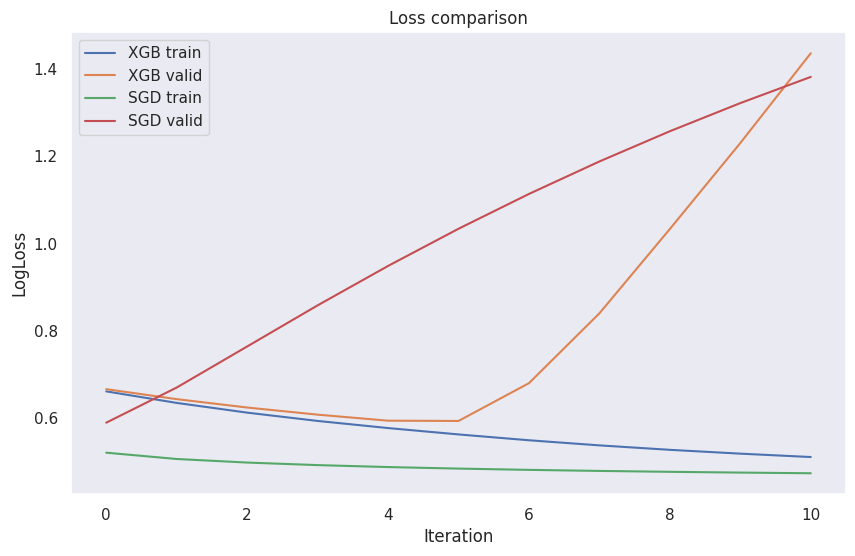

In [39]:
plt.figure(figsize=(10, 6))

plt.plot(xgb_train_loss, label="XGB train")
plt.plot(xgb_valid_loss, label="XGB valid")

plt.plot(sgd_train_loss, label="SGD train")
plt.plot(sgd_valid_loss, label="SGD valid")

plt.xlabel("Iteration")
plt.ylabel("LogLoss")
plt.title("Loss comparison")

plt.legend()
plt.grid()

plt.show()

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** Какой вывод вы можете сделать?

**Ответ:** Прежде чем ответить на вопрос - Сделал версию с early_stopping для борьбы с переобучением, т к в прошлых заданиях делал именно так (это реально работало), тут для чистоты экспериманта сделал то же самое, смотрел и без early_stopping, но было хуже, немного, но хуже, по графикам видно, что с увеличением итераций лосс на валидации уже заметно начинает расти, поэтому early_stopping нужен. 

На графике видно, что train loss у обеих моделей уменьшается. В целом линейные модели заметно уступают бустингу деревьев в нашей задаче, т к линейные модели хуже описывают нелинейные зависимости в данных

Кроме того, XGBoost gblinear обучался быстрее, однако SGDClassifier показал более стабильную сходимость и немного лучшее качество на valid/test 

</div>

### 💠 2.11. Потери потерь (0.5 балла)

Если вы смотрели в датасет, то вероятно заметили, что данные в нём несбалансированы. С этим можно жить, и этому вы научитесь на мо2, но нужно ли? Ведь всегда можно шлёпнуть простой советский проверенный способ, который в бустингах применяется не слишком широко, по непонятной, честно говоря, причине.

Смотрите, какая существует штука:

$$
\text{FocalLoss}(y, z) = -\frac{1}{n}\sum_{i=1}^{n} \left(1 - \sigma(y_i z_i)\right)^{\gamma} \log\!\big(\sigma(y_i z_i)\big)
$$

Что же это за покемон?
- параметр $\gamma$ (это другой гамма, свой, не бустинговый) регулирует, как сильно я акцентирую внимание на тех объектах, которых много, и которые легко разметить. Чем он больше, тем больше игнорим лёгкие примеры
- вес $(1 - \sigma(y_i z_i))$ регулирует вклад в лосс, в зависимости от класса
- в остальном это тот же логлосс

>Если разметить объект легко, то есть сигмоида даёт результат, близкий к единице, то нам как бы максимально всё равно, какой у него вклад в лосс, множитель под гаммой будет примерно 0, интереснее же на сложных примерах обучаться. А если сложно, то вклад напротив максимальный, объект полностью участвует в расчёте лосса

Хочется увидеть в классе `Boosting`:
- `loss: str = 'BCE` — лосс, на который обучаем бустинг, по дефолту `'BCE'` - бинарная кросс-энтропия, aka логистическая функция потерь
- `focal_gamma: float = 2.0` — гиперпараметр для силы фокал лосса, чем-то похож на `class_weights`, но поинтереснее
- методы `loss_fn` и `grad_fn` для фокал лосса

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>objective="custom"</code></td>
<td align="center"><code>objective="custom"</code></td>
<td align="center"><code>loss_function="FocalLoss"</code></td>
</tr>
</table>

</div>

Получилось? Покажите. Должно было стать чуть получше

In [40]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
from __future__ import annotations

from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeRegressor

from tqdm.auto import tqdm

from sklearn.base import ClassifierMixin


class Boosting2_11(ClassifierMixin):

    def __init__(
            self,
            base_model_class=DecisionTreeRegressor,
            base_model_params: dict | None = None,
            n_estimators: int = 20,
            learning_rate: float = 0.05,
            random_state: int | None = None,
            verbose: bool = True,
            early_stopping_rounds: int | None = 0,
            eval_metric: str | None = None,
            l2: float | None = 0.0,
            feature_types=None,
            subsample: float = 1.0,
            bagging_temperature: float = 1.0,
            bootstrap_type: str | None = "Bernoulli",
            rsm: float = 1.0,
            goss: bool = False,
            goss_k: float = 0.2,
            quantization_type: str | None = None,
            nbins: int = 255,
            dart: bool = False,
            dropout_rate: float = 0.05,
            loss: str = "BCE",
            focal_gamma: float = 2.0,
    ):
        super().__init__()

        self.base_model_class = base_model_class
        self.base_model_params = {} if base_model_params is None else base_model_params

        self.n_estimators = n_estimators
        self.learning_rate = learning_rate

        self.models = []
        self.gammas = []

        self.random_state = random_state  # не забудьте вставить его везде, где у вас возникает рандом
        self.verbose = verbose

        self.l2 = l2
        self.feature_types = feature_types

        self.dart = dart
        self.dropout_rate = dropout_rate

        self.goss = goss
        self.goss_k = goss_k

        self.loss = loss
        self.focal_gamma = focal_gamma

        self.subsample = subsample
        self.bagging_temperature = bagging_temperature
        self.bootstrap_type = bootstrap_type
        self.rsm = rsm

        self.quantization_type = quantization_type
        self.nbins = nbins
        self.quantizer = None

        self.early_stopping_rounds = early_stopping_rounds
        self.eval_metric = eval_metric

        self.history = defaultdict(list)  # {"train_roc_auc": [], "train_loss": [], ...}

        self.sigmoid = lambda x: 1 / (1 + np.exp(-x))

        def bce_loss(y, z):
            return -np.log(self.sigmoid(y * z) + 1e-15).mean()

        def bce_grad(y, z):
            return y / (1 + np.exp(y * z))

        def focal_loss(y, z):
            p = self.sigmoid(y * z)
            return -(((1 - p) ** self.focal_gamma) * np.log(p + 1e-15)).mean()

        def focal_grad(y, z):
            p = self.sigmoid(y * z)
            gamma = self.focal_gamma

            return (y
                    * ((1 - p) ** gamma)
                    * (1 - p - gamma * p * np.log(p + 1e-15)))

        if self.loss == "BCE":
            self.loss_fn = bce_loss
            self.grad_fn = bce_grad
        elif self.loss == "Focal":
            self.loss_fn = focal_loss
            self.grad_fn = focal_grad
        self.hess_fn = lambda y, z: self.sigmoid(y * z) * self.sigmoid(-y * z)

    def partial_fit(self, X: np.ndarray, y: np.ndarray) -> None:
        antigrad = self.grad_fn(y, self.train_predictions)
        hess = self.hess_fn(y, self.train_predictions)

        if self.dart and len(self.models) > 0:

            keep_mask = (
                    np.random.rand(len(self.models))
                    > self.dropout_rate
            )

            if keep_mask.sum() == 0:
                keep_mask[np.random.randint(0, len(self.models))] = True

            dropped_count = len(self.models) - keep_mask.sum()

            dropped_predictions = np.zeros(X.shape[0])

            for i in range(len(self.models)):
                if keep_mask[i]:
                    feature_mask = self.feature_masks[i]

                    dropped_predictions += (
                            self.learning_rate
                            * self.gammas[i]
                            * self.models[i].predict(X[:, feature_mask])
                    )

            antigrad = self.grad_fn(y, dropped_predictions)
            hess = self.hess_fn(y, dropped_predictions)

        else:
            dropped_count = 0

        X_full = X
        n_objects = X.shape[0]
        n_features = X.shape[1]

        if self.goss:
            grad_abs = np.abs(antigrad)

            n_large = max(1, int(self.goss_k * n_objects))
            large_idx = np.argsort(grad_abs)[-n_large:]

            small_mask = np.ones(n_objects, dtype=bool)
            small_mask[large_idx] = False
            small_idx = np.where(small_mask)[0]

            sampled_small = small_idx[
                np.random.rand(len(small_idx)) < self.subsample
                ]

            selected_idx = np.concatenate([large_idx, sampled_small])

            small_weight = (1 - self.goss_k) / self.subsample

            weights = np.ones(len(selected_idx))
            weights[len(large_idx):] = small_weight

            X = X[selected_idx]
            antigrad = antigrad[selected_idx] * weights
            hess = hess[selected_idx] * weights

            object_mask = np.ones(X.shape[0], dtype=bool)
            sample_weight = None

        else:
            if self.bootstrap_type == "Bernoulli":
                object_mask = np.random.rand(n_objects) < self.subsample

                if object_mask.sum() == 0:
                    object_mask[np.random.randint(0, n_objects)] = True

                sample_weight = None

            elif self.bootstrap_type == "Bayesian":
                object_mask = np.ones(n_objects, dtype=bool)

                x_random = np.random.rand(n_objects)
                sample_weight = (-np.log(x_random)) ** self.bagging_temperature

            else:
                object_mask = np.ones(n_objects, dtype=bool)
                sample_weight = None

        feature_mask = np.random.rand(n_features) < self.rsm

        if feature_mask.sum() == 0:
            feature_mask[np.random.randint(0, n_features)] = True

        X_part = X[object_mask][:, feature_mask]
        antigrad_part = antigrad[object_mask]
        hess_part = hess[object_mask]

        if sample_weight is not None:
            sample_weight_part = sample_weight[object_mask]
            antigrad_part = antigrad_part * sample_weight_part
            hess_part = hess_part * sample_weight_part

        params = self.base_model_params.copy()

        if self.l2 is not None and self.l2 != 0:
            feature_types_part = []

            for i in range(len(feature_mask)):
                if feature_mask[i]:
                    feature_types_part.append(self.feature_types[i])

            model = self.base_model_class(
                feature_types=feature_types_part,
                max_depth=params.get("max_depth"),
                min_samples_split=params.get("min_samples_split"),
                min_samples_leaf=params.get("min_samples_leaf"),
                l2=self.l2,
            )

            model.fit(X_part, antigrad_part, hess_part)
            new_predictions = model.predict(X_full[:, feature_mask])
            gamma = 1.0

            if self.dart and dropped_count > 0:
                gamma = gamma / (dropped_count + 1)

                scale = dropped_count / (dropped_count + 1)

                for i in range(len(self.gammas)):
                    self.gammas[i] *= scale

                self.train_predictions = np.zeros(X_full.shape[0])

                for i in range(len(self.models)):
                    old_feature_mask = self.feature_masks[i]
                    self.train_predictions += (
                            self.learning_rate
                            * self.gammas[i]
                            * self.models[i].predict(X_full[:, old_feature_mask])
                    )

        else:
            if self.random_state is not None:
                params["random_state"] = self.random_state

            model = self.base_model_class(**params)
            model.fit(X_part, antigrad_part)

            new_predictions = model.predict(X_full[:, feature_mask])

            gamma = self._find_optimal_gamma(
                y,
                self.train_predictions,
                new_predictions,
            )

        self.models.append(model)
        self.gammas.append(gamma)
        self.feature_masks.append(feature_mask)

        self.train_predictions += self.learning_rate * gamma * new_predictions

    def fit(
            self,
            X_train: np.ndarray,
            y_train: np.ndarray,
            eval_set: tuple[np.ndarray, np.ndarray] | None = None,
            use_best_model: bool = False,
    ) -> None:
        self.classes_ = np.unique(y_train)  # не рекомендуется убирать, нужно для калибровки
        self.models = []
        self.gammas = []
        self.feature_masks = []
        self.history = defaultdict(list)
        if self.quantization_type is not None:
            self.quantizer = Quantizer(
                feature_types=self.feature_types,
                quantization_type=self.quantization_type,
                nbins=self.nbins,
            )

            self.quantizer.fit(X_train, y_train)
            X_train = self.quantizer.transform(X_train)

            if eval_set is not None:
                X_valid, y_valid = eval_set
                X_valid = self.quantizer.transform(X_valid)
                eval_set = (X_valid, y_valid)
        self.train_predictions = np.zeros(X_train.shape[0])

        if eval_set is not None:
            X_valid, y_valid = eval_set
        else:
            X_valid, y_valid = None, None

        best_score = None
        best_iteration = 0
        bad_rounds = 0

        estimator_range = range(self.n_estimators)
        if self.verbose:
            estimator_range = tqdm(estimator_range)

        # ! YOUR CODE HERE !
        for i in estimator_range:
            self.partial_fit(X_train, y_train)
            train_loss = self.loss_fn(y_train, self.train_predictions)
            train_auc = roc_auc_score(y_train == 1, self.sigmoid(self.train_predictions))
            self.history["train_loss"].append(train_loss)
            self.history["train_roc_auc"].append(train_auc)
            if eval_set is not None:

                valid_predictions = np.zeros(X_valid.shape[0])

                for j in range(len(self.models)):
                    feature_mask_j = self.feature_masks[j]
                    valid_predictions += (
                            self.learning_rate
                            * self.gammas[j]
                            * self.models[j].predict(X_valid[:, feature_mask_j])
                    )
                valid_loss = self.loss_fn(y_valid, valid_predictions)
                valid_auc = roc_auc_score(y_valid == 1, self.sigmoid(valid_predictions))
                self.history["valid_loss"].append(valid_loss)
                self.history["valid_roc_auc"].append(valid_auc)
                metric_name = self.eval_metric
                if metric_name is None:
                    metric_name = "valid_loss"
                current_score = self.history[metric_name][-1]
                if "loss" in metric_name:
                    is_better = best_score is None or current_score < best_score
                else:
                    is_better = best_score is None or current_score > best_score
                if is_better:
                    best_score = current_score
                    best_iteration = i
                    bad_rounds = 0
                else:
                    bad_rounds += 1

                if self.early_stopping_rounds and bad_rounds >= self.early_stopping_rounds:
                    if self.verbose:
                        print(f"Early stopping on iteration {i + 1}")
                    break

        if use_best_model and eval_set is not None and self.early_stopping_rounds:
            self.models = self.models[:best_iteration + 1]
            self.gammas = self.gammas[:best_iteration + 1]
            self.feature_masks = self.feature_masks[:best_iteration + 1]

        # чтобы было удобнее смотреть
        for key in self.history:
            self.history[key] = np.array(self.history[key])

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        # ! YOUR CODE HERE !
        if self.quantizer is not None:
            X = self.quantizer.transform(X)
        predictions = np.zeros(X.shape[0])
        for i in range(len(self.models)):
            feature_mask = self.feature_masks[i]
            predictions += (
                    self.learning_rate
                    * self.gammas[i]
                    * self.models[i].predict(X[:, feature_mask])
            )
        proba_1 = self.sigmoid(predictions)
        proba_0 = 1 - proba_1
        return np.vstack([proba_0, proba_1]).T

    def plot_history(self, keys):
        if isinstance(keys, str):
            keys = [keys]
        for key in keys:
            plt.plot(self.history[key], label=key)
        plt.xlabel("iteration")
        plt.ylabel("metric")
        plt.legend()
        plt.grid()
        plt.show()

    def _find_optimal_gamma(
            self,
            y: np.ndarray,
            old_predictions: np.ndarray,
            new_predictions: np.ndarray
    ) -> float:
        gammas = np.linspace(start=0, stop=1, num=100)
        losses = [
            self.loss_fn(y, old_predictions + gamma * new_predictions)
            for gamma in gammas
        ]
        return gammas[np.argmin(losses)]

    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        return roc_auc_score(y == 1, self.predict_proba(X)[:, 1])

    def get_feature_importance(self, X=None, y=None, type="gain"):
        importances = np.zeros(len(self.feature_types))

        for i in range(len(self.models)):
            model = self.models[i]
            feature_mask = self.feature_masks[i]
            used_features = np.where(feature_mask)[0]

            if not hasattr(model, "feature_importances_"):
                continue

            model_importances = model.feature_importances_

            for j in range(len(used_features)):
                feature = used_features[j]
                importances[feature] += self.gammas[i] * model_importances[j]

        importances = np.maximum(importances, 0)

        if importances.sum() > 0:
            importances = importances / importances.sum()

        return importances


In [41]:
boosting_focal = Boosting2_11(
    base_model_class=DecisionTree,
    base_model_params=dict(
        max_depth=4,
        min_samples_leaf=100,
        min_samples_split=100,
    ),

    n_estimators=50,
    learning_rate=0.05,

    verbose=True,
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",

    l2=0.5,
    feature_types=feature_types,

    quantization_type="quantile",
    nbins=32,

    goss=True,
    goss_k=0.2,
    subsample=0.3,

    dart=True,
    dropout_rate=0.05,

    loss="Focal",
    focal_gamma=2.0,
)

boosting_focal.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)

print(f"Train ROC-AUC {boosting_focal.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC {boosting_focal.score(X_valid, y_valid):.4f}")
print(f"Test ROC-AUC {boosting_focal.score(X_test, y_test):.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

Early stopping on iteration 30
Train ROC-AUC 0.8075
Valid ROC-AUC 0.7652
Test ROC-AUC 0.7588


------

## Задание 3. Около бустинга (📌 1 балл |💠 1.25 балла)

Теперь давайте проанализируем, как же правильно готовить бустинги. Нас интересует: как тюнить бустинги, какие они вообще бывают и как их интерпретировать. Посмотрим на все это по порядку

### 📌 3.1. Optuna наносит ответный удар (0.5 балла)

Если вы помните, у нас уже было знакомство с библиотекой `optuna` для подбора гиперпараметров. Вспомним, как это делается и подумаем, как это можно делать еще лучше

Подберите на валидации оптимальные значения следующих гиперпараметров для вашей реализации бустинга:
- `max_depth`
- `n_estimators`
- `learning_rate`
- любые другие, которые вы сделали в части 2

Подберите диапазон параметров самостоятельно, не забывайте фиксировать сид (нет, его не нужно перебирать). Сохраните и покажите оптимальный набор параметров. Покажите, какие из них дали наибольший прирост.

In [42]:
!pip install optuna -q
import optuna

In [44]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
from boosting import Boosting #беру из boosting.py, который прикрепил в anytask
def objective(study, model="custom_boosting"):

    # параметры бустинга
    boosting_params = dict(
        n_estimators=study.suggest_int("n_estimators", 100, 300),
        learning_rate=study.suggest_float("learning_rate", 0.02, 0.08),
        early_stopping_rounds=10,
        eval_metric="valid_roc_auc",
        cat_features=[6, 10],
    )

    # параметры дерева
    tree_params = dict(
        max_depth=study.suggest_int("max_depth", 3, 7),
        min_samples_leaf=study.suggest_int("min_samples_leaf", 1, 80),
        min_samples_split=study.suggest_int("min_samples_split", 2, 120),
    )

    # параметры, зависящие от некоторого условия (e.g. subsample только для Bernoulli)
    # если не делать их условными, можно испортить процесс оптимизации
    conditional_params = {}

    model = Boosting(
        base_model_params=tree_params,
        random_state=69,
        verbose=False,
        **boosting_params,
        **conditional_params,
    )
    
    model.fit(
        X_train,
        y_train,
        eval_set=(X_valid, y_valid),
        use_best_model=True,
    )

    return model.score(X_valid, y_valid)


In [45]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=10)

print("Best ROC-AUC:", study.best_value)
print("Best params:")
print(study.best_params)

[I 2026-05-28 18:09:35,576] A new study created in memory with name: no-name-9977efe2-27f7-4bc8-b92b-d78bc9bea31c
[I 2026-05-28 18:10:03,618] Trial 0 finished with value: 0.8065986421975351 and parameters: {'n_estimators': 210, 'learning_rate': 0.07713544074946138, 'max_depth': 5, 'min_samples_leaf': 51, 'min_samples_split': 11}. Best is trial 0 with value: 0.8065986421975351.
[I 2026-05-28 18:11:00,360] Trial 1 finished with value: 0.8010636601420876 and parameters: {'n_estimators': 238, 'learning_rate': 0.05107844342557159, 'max_depth': 6, 'min_samples_leaf': 77, 'min_samples_split': 71}. Best is trial 0 with value: 0.8065986421975351.
[I 2026-05-28 18:12:12,377] Trial 2 finished with value: 0.7969159420435674 and parameters: {'n_estimators': 279, 'learning_rate': 0.05536997389361349, 'max_depth': 7, 'min_samples_leaf': 30, 'min_samples_split': 20}. Best is trial 0 with value: 0.8065986421975351.
[I 2026-05-28 18:13:10,915] Trial 3 finished with value: 0.8008574636229566 and paramete

Best ROC-AUC: 0.8144044185469566
Best params:
{'n_estimators': 132, 'learning_rate': 0.03424182972035793, 'max_depth': 4, 'min_samples_leaf': 39, 'min_samples_split': 69}


In [46]:
best_model_custom = Boosting(
    base_model_params=dict(
        max_depth=study.best_params["max_depth"],
        min_samples_leaf=study.best_params["min_samples_leaf"],
        min_samples_split=study.best_params["min_samples_split"],
    ),
    n_estimators=study.best_params["n_estimators"],
    learning_rate=study.best_params["learning_rate"],
    early_stopping_rounds=10,
    eval_metric="valid_roc_auc",
    cat_features=[6, 10],
    random_state=69,
    verbose=False,
)
best_model_custom.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
)
print(f"Train ROC-AUC {best_model_custom.score(X_train, y_train):.4f}")
print(f"Valid ROC-AUC {best_model_custom.score(X_valid, y_valid):.4f}")
print(f"Test ROC-AUC {best_model_custom.score(X_test, y_test):.4f}")

Train ROC-AUC 0.8698
Valid ROC-AUC 0.8144
Test ROC-AUC 0.8084


Выбейте ROC-AUC хотя бы 0.8, и можете двигаться дальше

### 📌 3.2. Готовые реализации (0.5 балла)

Библиотек для бустингов существует много, но активно используются лишь три. Вам предстоит попробовать их в деле, посмотреть на их уникальные фишки и понять, что вам нравится больше всего

Возьмите любую из популярных библиотек: <font color='#2f82d4'>**XGBoost**</font>, <font color='#53c96c'>**LightGBM**</font> или <font color='#c4bf0a'>**CatBoost**</font>.
Ваша задача — взять одну из них, подобрать те же оптимальные параметры, что и выше, а также вставить [прунер](https://optuna.readthedocs.io/en/stable/reference/pruners.html).

Идея прунера — не обучать бустинг до конца, если по истории валидации видно, что другие бустинги на этом этапе статистически лучше, для этого мы и делали `partial_fit`, но в готовые реализации его можно вставить при помощи CallBack, для этого придётся немножко погуглить. Это во-первых, заметно ускоряет процесс перебора гиперпарамтеров, во-вторых неявно регуляризует модельку

Цель — увидеть в логах оптуны `Trial.PRUNED`, это знак того, что прунер работает. Если вы этого не видите, вероятно, вы вставили его неправильно.

In [47]:
!pip install catboost optuna optuna-integration -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 4.9 MB/s eta 0:00:00


In [48]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
import optuna

from catboost import CatBoostClassifier
from optuna.integration import CatBoostPruningCallback
from sklearn.metrics import roc_auc_score

y_train_01 = (y_train == 1).astype(int)
y_valid_01 = (y_valid == 1).astype(int)
y_test_01 = (y_test == 1).astype(int)

cat_features = [6, 10]

# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
def objective(trial):

    # параметры бустинга
    boosting_params = dict(
        iterations=trial.suggest_int("iterations", 100, 500),
        learning_rate=trial.suggest_float("learning_rate", 0.02, 0.15),
        depth=trial.suggest_int("depth", 3, 8),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        random_strength=trial.suggest_float("random_strength", 0.0, 5.0),
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=69,
        verbose=False,
        allow_writing_files=False,
    )

    # параметры, зависящие от некоторого условия (e.g. subsample только для Bernoulli)
    # если не делать их условными, можно испортить процесс оптимизации
    conditional_params = {}

    model = CatBoostClassifier(**boosting_params)

    pruning_callback = CatBoostPruningCallback(trial, "AUC")
    
    model.fit(
        X_train,
        y_train_01,
        cat_features=cat_features,
        eval_set=(X_valid, y_valid_01),
        callbacks=[pruning_callback],
        verbose=False,
    )

    pruning_callback.check_pruned()

    valid_pred = model.predict_proba(X_valid)[:, 1]
    return roc_auc_score(y_valid_01, valid_pred)


In [49]:
study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=3,
        n_warmup_steps=20,
    ),
)

study.optimize(objective, n_trials=10)

print("Best ROC-AUC:", study.best_value)
print("Best params:")
print(study.best_params)

[I 2026-05-28 18:27:33,442] A new study created in memory with name: no-name-8ad2dc33-b4be-45c7-a7be-8bfd79a7ceb9
[I 2026-05-28 18:28:30,292] Trial 0 finished with value: 0.8224388449121487 and parameters: {'iterations': 456, 'learning_rate': 0.09370764932509333, 'depth': 5, 'l2_leaf_reg': 7.923763320050066, 'random_strength': 2.6322430709287175}. Best is trial 0 with value: 0.8224388449121487.
[I 2026-05-28 18:28:36,295] Trial 1 finished with value: 0.8213872174281851 and parameters: {'iterations': 126, 'learning_rate': 0.0963732988017257, 'depth': 3, 'l2_leaf_reg': 8.973506312803295, 'random_strength': 0.5433804429268801}. Best is trial 0 with value: 0.8224388449121487.
[I 2026-05-28 18:29:40,022] Trial 2 finished with value: 0.8169603737651912 and parameters: {'iterations': 360, 'learning_rate': 0.14702743183220335, 'depth': 8, 'l2_leaf_reg': 1.5829883835859917, 'random_strength': 1.2035820668607484}. Best is trial 0 with value: 0.8224388449121487.
[I 2026-05-28 18:29:43,423] Trial 

Best ROC-AUC: 0.8224388449121487
Best params:
{'iterations': 456, 'learning_rate': 0.09370764932509333, 'depth': 5, 'l2_leaf_reg': 7.923763320050066, 'random_strength': 2.6322430709287175}


In [50]:
best_model = CatBoostClassifier(
    **study.best_params,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=69,
    verbose=False,
    allow_writing_files=False,
)

best_model.fit(
    X_train,
    y_train_01,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid_01),
    verbose=False,
)

print(f"Train ROC-AUC {roc_auc_score(y_train_01, best_model.predict_proba(X_train)[:, 1]):.4f}")
print(f"Valid ROC-AUC {roc_auc_score(y_valid_01, best_model.predict_proba(X_valid)[:, 1]):.4f}")
print(f"Test ROC-AUC {roc_auc_score(y_test_01, best_model.predict_proba(X_test)[:, 1]):.4f}")

Train ROC-AUC 0.8931
Valid ROC-AUC 0.8224
Test ROC-AUC 0.8067


<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** Какая архитектура вам нравится больше всего и почему?

**Ответ:** Для этой задачи мне понравилась архитектура CatBoost. Она показывает лучшее качество на наших данных, потому что умеет работать с категориальными признаками без необходимости вручную делать one hot encoding. Для задачи это важно т к признаки occ и occupation оказались самыми информативными. Так же катбуст хорошо интегрируется с Оptuna. Pruner работает - в логах видно, что есть попытки со статусом Trial pruned. В итоге всё четко и все довольны

</div>

### 💠 3.3. <font color='#2f82d4'>**XGBoost**</font> и велосипеды (0.25 баллов)

<font color='#2f82d4'>**XGBoost**</font> известен тем, что в нем впервые повилась регуляризация. Ручками ее написать сложно, и вы даже могли попробовать пунктом ранее, но зачем? Она уже написана, вообще-то. Вместо того, чтобы заниматься ерундой, можем попробовать импортировать и посмотреть, насколько она полезна в лучшем своём представлении.

Добавьте оба вида регуляризации, что там есть, как параметры в оптуну, и прогоните процесс оптимизации только на них.

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>alpha</code>, <code>lambda</code></td>
<td align="center"><code>lambda_l1</code>, <code>lambda_l2</code></td>
<td align="center"><code>-</code>, <code>l2_leaf_reg</code></td>
</tr>
</table>

</div>

In [51]:
def objective_xgb_reg(trial):
    model = XGBClassifier(
        n_estimators=110,
        learning_rate=0.13,
        max_depth=6,
        reg_alpha=trial.suggest_float(
            "reg_alpha",
            1e-5,
            10.0,
            log=True,
        ),
        reg_lambda=trial.suggest_float(
            "reg_lambda",
            1e-5,
            10.0,
            log=True,
        ),
        objective="binary:logistic",
        eval_metric="auc",
        random_state=69,
        n_jobs=-1,
    )
    model.fit(
        X_train_lin,
        y_train_01,
        eval_set=[(X_valid_lin, y_valid_01)],
        verbose=False,
    )

    valid_pred = model.predict_proba(X_valid_lin)[:, 1]

    return roc_auc_score(y_valid_01, valid_pred)

In [52]:
study_xgb_reg = optuna.create_study(direction="maximize")

study_xgb_reg.optimize(
    objective_xgb_reg,
    n_trials=10,
)

print("Best ROC-AUC:", study_xgb_reg.best_value)
print("Best params:")
print(study_xgb_reg.best_params)

[I 2026-05-28 18:35:40,328] A new study created in memory with name: no-name-5452dd65-f831-4fff-a339-f0f1c0d8afd4
[I 2026-05-28 18:37:25,932] Trial 0 finished with value: 0.7716924159124205 and parameters: {'reg_alpha': 0.8184487753206515, 'reg_lambda': 1.8675184440644046e-05}. Best is trial 0 with value: 0.7716924159124205.
[I 2026-05-28 18:39:11,278] Trial 1 finished with value: 0.7662321356556586 and parameters: {'reg_alpha': 1.932948170084457, 'reg_lambda': 8.208469081729946}. Best is trial 0 with value: 0.7716924159124205.
[I 2026-05-28 18:40:57,034] Trial 2 finished with value: 0.7743942374955681 and parameters: {'reg_alpha': 0.0003389830667254448, 'reg_lambda': 7.36115015220112e-05}. Best is trial 2 with value: 0.7743942374955681.
[I 2026-05-28 18:42:42,564] Trial 3 finished with value: 0.7720750017339334 and parameters: {'reg_alpha': 1.670781181274805e-05, 'reg_lambda': 0.3313185841058245}. Best is trial 2 with value: 0.7743942374955681.
[I 2026-05-28 18:44:27,977] Trial 4 fini

Best ROC-AUC: 0.7743950207891495
Best params:
{'reg_alpha': 4.855805554658511e-05, 'reg_lambda': 1.0265471941854107e-05}


In [53]:
best_xgb_reg = XGBClassifier(
    n_estimators=110,
    learning_rate=0.13,
    max_depth=6,

    reg_alpha=study_xgb_reg.best_params["reg_alpha"],
    reg_lambda=study_xgb_reg.best_params["reg_lambda"],

    objective="binary:logistic",
    eval_metric="auc",

    random_state=69,
    n_jobs=-1,
)

best_xgb_reg.fit(
    X_train_lin,
    y_train_01,
    eval_set=[(X_valid_lin, y_valid_01)],
    verbose=False,
)

print(f"Train ROC-AUC {roc_auc_score(y_train_01, best_xgb_reg.predict_proba(X_train_lin)[:, 1]):.4f}")
print(f"Valid ROC-AUC {roc_auc_score(y_valid_01, best_xgb_reg.predict_proba(X_valid_lin)[:, 1]):.4f}")
print(f"Test ROC-AUC {roc_auc_score(y_test_01, best_xgb_reg.predict_proba(X_test_lin)[:, 1]):.4f}")

Train ROC-AUC 0.8773
Valid ROC-AUC 0.7744
Test ROC-AUC 0.7669


<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** Насколько регуляризация вообще эффективна?

**Ответ:** Регуляризация эффективна для борьбы с переобучением. Протестировал на данных (в ячейках выше) XGBoost, с регуляризацией ROC AUC лучше но не сильно, так и должно быть. Регуляризация не делает модель намного лучше, но помогает сделать обучение стабильным и улучшить обобщающую способность модели

</div>

### 💠 3.4. <font color='#53c96c'>**LightGBM**</font>, лес vs бустинг (0.25 балла)

<font color='#53c96c'>**LightGBM**</font> велик по многим причинам. В нём самое большое количество гиперпараметров из всех библиотек. А ещё он содержит в себе реализацию своего злейшего врага — случайный лес, это очень по-философски.

Посмотрите, какие есть параметры у него, обучите так сильно, как только сможете (не забудьте про свойства случайного леса к переобучению, про категориальные энкодеры и прочее).

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>num_parallel_tree</code></td>
<td align="center"><code>boosting_type="rf"</code></td>
<td align="center"><code>-</code></td>
</tr>
</table>

</div>

In [54]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
!pip install lightgbm -q

import lightgbm as lgb

In [58]:
feature_names = [
    "region", "age", "year", "race", "sch",
    "empstat", "occ", "annhrs", "hrwage",
    "incwage", "occupation",
]

X_train_lgb = pd.DataFrame(X_train, columns=feature_names)
X_valid_lgb = pd.DataFrame(X_valid, columns=feature_names)
X_test_lgb = pd.DataFrame(X_test, columns=feature_names)

numeric_features_lgb = [
    "region", "age", "year", "race", "sch",
    "empstat", "annhrs", "hrwage", "incwage",
]

cat_features_lgb = ["occ", "occupation"]

for col in numeric_features_lgb:
    X_train_lgb[col] = X_train_lgb[col].astype(float)
    X_valid_lgb[col] = X_valid_lgb[col].astype(float)
    X_test_lgb[col] = X_test_lgb[col].astype(float)

for col in cat_features_lgb:
    X_train_lgb[col] = X_train_lgb[col].astype("category")
    X_valid_lgb[col] = X_valid_lgb[col].astype("category")
    X_test_lgb[col] = X_test_lgb[col].astype("category")

In [59]:
def objective_lgb_rf(trial):

    model = lgb.LGBMClassifier(
        boosting_type="rf",
    
        n_estimators=trial.suggest_int("n_estimators", 200, 800),
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.10),
    
        max_depth=trial.suggest_int("max_depth", 4, 10),
        num_leaves=trial.suggest_int("num_leaves", 16, 128),
    
        subsample=trial.suggest_float("subsample", 0.6, 0.9),
        subsample_freq=1,
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 0.9),
    
        min_child_samples=trial.suggest_int("min_child_samples", 10, 50),
    
        reg_alpha=trial.suggest_float("reg_alpha", 1e-5, 5.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-5, 5.0, log=True),
    
        random_state=69,
        n_jobs=-1,
    
        verbose=-1,
        force_row_wise=True,
    )

    model.fit(
        X_train_lgb,
        y_train_01,
        categorical_feature=cat_features_lgb,
        eval_set=[(X_valid_lgb, y_valid_01)],
    )

    valid_pred = model.predict_proba(X_valid_lgb)[:, 1]

    return roc_auc_score(y_valid_01, valid_pred)

In [60]:
study_lgb_rf = optuna.create_study(direction="maximize")

study_lgb_rf.optimize(
    objective_lgb_rf,
    n_trials=10,
)

print("Best ROC-AUC:", study_lgb_rf.best_value)
print("Best params:")
print(study_lgb_rf.best_params)

[I 2026-05-28 18:58:12,916] A new study created in memory with name: no-name-a2b649c8-8b9a-4018-b7c5-7ebb110708f2
[I 2026-05-28 18:58:21,602] Trial 0 finished with value: 0.8221311436118557 and parameters: {'n_estimators': 365, 'learning_rate': 0.07284090969238852, 'max_depth': 8, 'num_leaves': 55, 'subsample': 0.8446433266798263, 'colsample_bytree': 0.7862392678522628, 'min_child_samples': 29, 'reg_alpha': 0.9999251737223088, 'reg_lambda': 0.00026252174229041077}. Best is trial 0 with value: 0.8221311436118557.
[I 2026-05-28 18:58:32,551] Trial 1 finished with value: 0.8142095639258179 and parameters: {'n_estimators': 503, 'learning_rate': 0.089901318840396, 'max_depth': 9, 'num_leaves': 34, 'subsample': 0.8029029511845753, 'colsample_bytree': 0.7091540953993829, 'min_child_samples': 36, 'reg_alpha': 0.00015090059042710958, 'reg_lambda': 0.0028463581638873414}. Best is trial 0 with value: 0.8221311436118557.
[I 2026-05-28 18:58:38,766] Trial 2 finished with value: 0.8266311583413605 a

Best ROC-AUC: 0.8283235682411754
Best params:
{'n_estimators': 633, 'learning_rate': 0.09520934943837964, 'max_depth': 9, 'num_leaves': 24, 'subsample': 0.7550668312616274, 'colsample_bytree': 0.8789322327019896, 'min_child_samples': 19, 'reg_alpha': 0.04061740022105319, 'reg_lambda': 0.00045785805109109864}


In [61]:
best_lgb_rf = lgb.LGBMClassifier(
    boosting_type="rf",
    **study_lgb_rf.best_params,
    subsample_freq=1,
    random_state=69,
    n_jobs=-1,
    verbose=-1,
    force_row_wise=True,
)

best_lgb_rf.fit(
    X_train_lgb,
    y_train_01,
    categorical_feature=cat_features_lgb,
)

print(f"Train ROC-AUC {roc_auc_score(y_train_01, best_lgb_rf.predict_proba(X_train_lgb)[:, 1]):.4f}")
print(f"Valid ROC-AUC {roc_auc_score(y_valid_01, best_lgb_rf.predict_proba(X_valid_lgb)[:, 1]):.4f}")
print(f"Test ROC-AUC {roc_auc_score(y_test_01, best_lgb_rf.predict_proba(X_test_lgb)[:, 1]):.4f}")

Train ROC-AUC 0.8713
Valid ROC-AUC 0.8283
Test ROC-AUC 0.8229


<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** Кто победит: бустинг или лес? и почему?

**Ответ:** В этой задаче победил лес т к модель хорошо справилась с категориальными признаками, LightGBM умеет эффективно работать с такими признаками без большого количества ручного препроцессинга.
random forest обучает деревья независимо друг от друга, поэтому модель получилась более устойчивой и меньше переобучалась (видно по разницу валид и теста, она небольшая) Возможно, что и зависимости в данных оказались не настолько сложными, чтобы бустинг показал заметный гэп над лесом

</div>

### 💠 3.5. Еще пара красивых слов про <font color='#c4bf0a'>**CatBoost**</font> (0.25 балла)

<font color='#c4bf0a'>**CatBoost**</font> славится ещё и кучей разных подходов к обучению деревьев, в частности он умеет мёрджить несколько моделей в одно. Это не стекинг, и даже не беггинг, а совершенно другой уровень. Поскольку бустинги это уже некоторая сумма деревьев, ничего не мешает брать и складывать уже сами бустинги между собой.

 Попробуйте разбить выборку на фолды и обучить по катбусту на каждом из них, а затем их склеить. Тюнить их не надо, он и так неплох, в этом его сила и мудрость.

<div align="center">

<table>
<tr>
<td align="center"><b><font color="#2f82d4">XGBoost</font></b></td>
<td align="center"><b><font color="#53c96c">LightGBM</font></b></td>
<td align="center"><b><font color="#c4bf0a">CatBoost</font></b></td>
</tr>
<tr>
<td align="center"><code>-</code></td>
<td align="center"><code>-</code></td>
<td align="center"><code>sum_models</code>, <code>to_classifier</code></td>
</tr>
</table>

</div>

Оцените, насколько это круто по 10-балльной

In [62]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
from catboost import CatBoostClassifier, sum_models, to_classifier
from sklearn.model_selection import KFold

In [63]:
feature_names = [
    "region", "age", "year", "race", "sch",
    "empstat", "occ", "annhrs", "hrwage",
    "incwage", "occupation",
]
X_full = pd.DataFrame(X_train, columns=feature_names)
X_test_cb = pd.DataFrame(X_test, columns=feature_names)
cat_features_cb = ["occ", "occupation"]
for col in cat_features_cb:
    X_full[col] = X_full[col].astype("category")
    X_test_cb[col] = X_test_cb[col].astype("category")

kf = KFold(n_splits=5, shuffle=True, random_state=69)
models = []
for train_index, valid_index in kf.split(X_full):
    model = CatBoostClassifier(
        iterations=404,
        learning_rate=0.147,
        depth=5,
        l2_leaf_reg=6.11,
        random_strength=2.79,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=69,
        verbose=False,
        allow_writing_files=False,
    )
    model.fit(
        X_full.iloc[train_index],
        y_train_01[train_index],
        cat_features=cat_features_cb,
        eval_set=(
            X_full.iloc[valid_index],
            y_train_01[valid_index],
        ),
    )
    models.append(model)
final_model = to_classifier(sum_models(models))
test_pred = final_model.predict_proba(X_test_cb)[:, 1]
print(f"Test ROC-AUC {roc_auc_score(y_test_01, test_pred):.4f}")

Test ROC-AUC 0.7998


Оценю на 7/10, идея интересная, но не столь эффективная на этом датасете

### 💠 3.6. Бустинг и вероятности (0.5 балла)

С качеством мы более-менее разобрались, но таки что насчет вероятностей? Постройте калибровочную кривую для вашей лучшей модели бустинга. Насколько хорошо бустинг оценивает вероятности?

In [64]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV
from sklearn.metrics import log_loss, brier_score_loss
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

boosting_model = best_model_custom
X_valid_boost = X_valid
X_test_boost = X_test

boosting_proba = boosting_model.predict_proba(X_test_boost)[:, 1]

logreg = LogisticRegression(
    max_iter=1000,
    random_state=69,
)

logreg.fit(X_train_lin, y_train_01)

logreg_proba = logreg.predict_proba(X_test_lin)[:, 1]


Постройте также калибровочную кривую для логистической регрессии, сравните их между собой. Проанализируйте полученные результаты.

<Figure size 800x600 with 0 Axes>

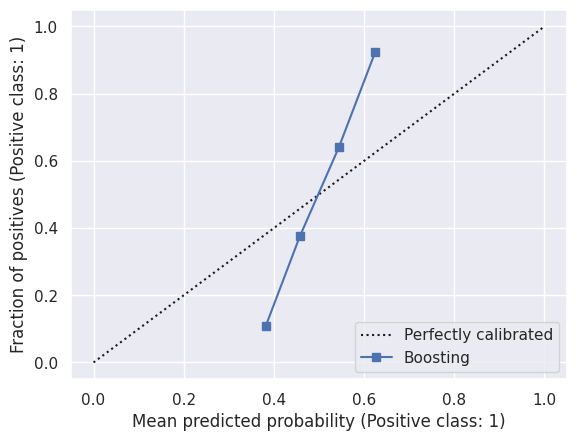

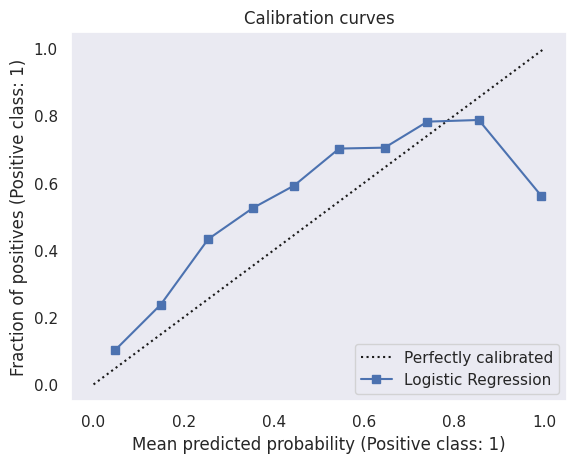

Boosting LogLoss: 0.6186908319127743
Boosting Brier: 0.21336727170499353
LogReg LogLoss: 6.071578083811265
LogReg Brier: 0.32742911684264064


In [65]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
plt.figure(figsize=(8, 6))

CalibrationDisplay.from_predictions(
    y_test_01,
    boosting_proba,
    n_bins=10,
    name="Boosting",
)

CalibrationDisplay.from_predictions(
    y_test_01,
    logreg_proba,
    n_bins=10,
    name="Logistic Regression",
)

plt.title("Calibration curves")
plt.grid()
plt.show()

print("Boosting LogLoss:", log_loss(y_test_01, boosting_proba))
print("Boosting Brier:", brier_score_loss(y_test_01, boosting_proba))

print("LogReg LogLoss:", log_loss(y_test_01, logreg_proba))
print("LogReg Brier:", brier_score_loss(y_test_01, logreg_proba))

ПО калибровочным прямым видно что бустинг оценивает вероятности лучше, чем логистическая регрессия. Его кривая находится ближе к диагонали, соответствующей идеально откалиброванной модели. У бустинга вероятности выглядят более стабильными и лучше соответствуют реальной доле положительных объектов

Конечно же, бустинг великолепен, как он есть, но можно сделать его еще лучше, если его откалибровать

1. Посмотрите на то, как это делать из библиотеки `sklearn`. Обратите внимание, передаете вы в него обученную модель или нет, а также на чем вы калибруетесь. Иначе есть риск что-то поломать
2. Откалибруйте вашу реализацию бустинга. Для этого за вас к нему был замешан `ClassifierMixin`
3. Покажите, как изменилась мера откалиброванности, для этого есть
$$\text{LogLoss} = -\frac{1}{N}\sum_{i} \sum_{k \in {0. 1}}\log p_k[y_i = k]; \qquad \text{BrierScore} = \frac{1}{N}\sum_{i} (p_i - y_i)^2;$$
4. Нарисуйте новую калибровочную кривую

<Figure size 800x600 with 0 Axes>

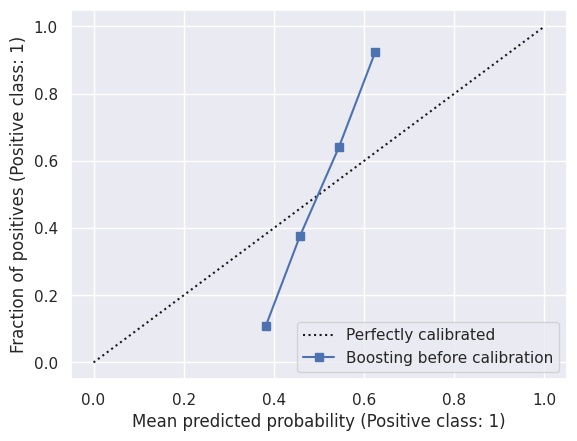

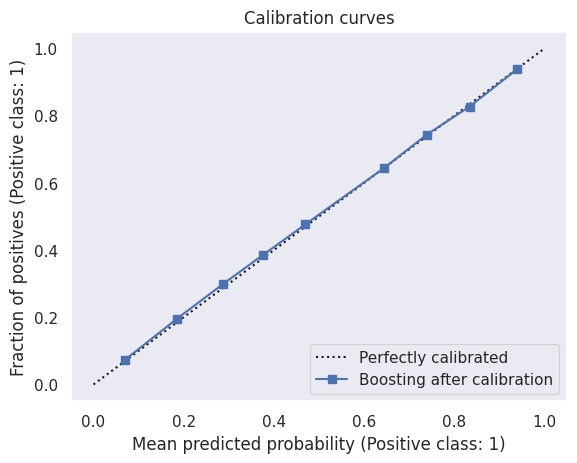

Before calibration LogLoss: 0.6186908319127743
Before calibration Brier: 0.21336727170499353
After calibration LogLoss: 0.5228214252481436
After calibration Brier: 0.17587328783796805


In [66]:
# *𖦹✿ෆ*𖤣❀*𖦹ᨒ❀*𖤓
calibrated_boosting = CalibratedClassifierCV(
    boosting_model,
    method="isotonic",
    cv="prefit",
)

calibrated_boosting.fit(
    X_valid_boost,
    y_valid_01,
)

boosting_calibrated_proba = calibrated_boosting.predict_proba(X_test_boost)[:, 1]

plt.figure(figsize=(8, 6))

CalibrationDisplay.from_predictions(
    y_test_01,
    boosting_proba,
    n_bins=10,
    name="Boosting before calibration",
)

CalibrationDisplay.from_predictions(
    y_test_01,
    boosting_calibrated_proba,
    n_bins=10,
    name="Boosting after calibration",
)

plt.title("Calibration curves")
plt.grid()
plt.show()

print("Before calibration LogLoss:", log_loss(y_test_01, boosting_proba))
print("Before calibration Brier:", brier_score_loss(y_test_01, boosting_proba))

print("After calibration LogLoss:", log_loss(y_test_01, boosting_calibrated_proba))
print("After calibration Brier:", brier_score_loss(y_test_01, boosting_calibrated_proba))


<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** Как вы можете прокомментировать то, что получилось?

**Ответ:** После калибровки качество вероятностей заметно улучшилось. Калибровочная кривая стала практически совпадать с диагональю идаельно откалиброванной модели, а значит что предсказанные вероятности стали соответсвовать реалбным вероятностям езе лучше

</div>

## Музыкальный бонус. (0.5 балла) 🎶

В честь окончания весны исполните песню, которая больше всего ассоциируется у вас с МО-1, будь то Ольга Бузова, Валентин Стрыкало, Игорь Вихорьков, Глеб Смирнов или любой другой заслуженный артист. Одни, в бойз или гёрлз-бенде, вокально или инструментально (например, вашему вниманию представляется раритетнейшая [аранжировка](https://disk.360.yandex.ru/i/mY8spsw_d6abLA) на незабвенную классику за авторством Михаила Шелега), проявите фантазию. 

In [67]:
from IPython.display import Audio, display
display(Audio(filename="/kaggle/input/datasets/alexetmercedes/hwbonus/bonus.mp3"))

При выполнении дз я также использовал ChatGPT как вспомогательный инструмент. Гптшка помогала исправлять баги, помогала разбирать многочисленные статьи из домашки и давала ориентиры на написание кода, проверяла на правильность. Так же помогала писать часто повторяющийся код для тестов и экспериментов, который от задания к заданию отличался не очень существенно. При этом основные модели, основные решения, а главное понимание что вообще происходит были достигнуты мной самостоятельно 